## Setup and  Import

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import missingno as msno

In [153]:
raw_df = pd.read_csv("ai_productivity_dataset_final.csv")
raw_df

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,2379.11,1514.73,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,709.95,335.27,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3243,T02060,Client_F,P056,mid,SEO,report,mid,2,3.0,high,...,688.97,807.57,-118.60,user_101,2025-12-31,in_progress,briefing,JIRA-90491,true,v1
3244,T02295,Client_K,P001,low,SEO,report,mid,1,2.0,high,...,570.64,671.72,-101.08,user_096,2026-03-05,in_progress,briefing,JIRA-19154,true,v3
3245,T02652,Client_C,P027,mid,Content,dev,junior,4,3.0,medium,...,1419.09,1303.74,115.35,user_080,2025-11-20,in_progress,execution,JIRA-32851,true,v4
3246,T01915,Client_F,P016,mid,SEO,ticket,mid,3,3.0,medium,...,285.28,273.58,11.70,user_011,2026-01-08,review,client_review,NaN,false,v1


In [154]:
#nomi colonne
raw_df.columns  


Index(['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type',
       'seniority', 'task_complexity_score', 'brief_quality_score',
       'deadline_pressure', 'scope_change_flag', 'pricing_model', 'created_at',
       'delivered_at', 'sla_days', 'sla_breach', 'hours_spent',
       'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors',
       'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit',
       'created_by', 'updated_at', 'task_status', 'workflow_stage',
       'jira_ticket', 'legacy_ai_flag', 'content_version'],
      dtype='str')

In [155]:
raw_df["task_id"].value_counts()

task_id
T00010    2
T00139    2
T00170    2
T00205    2
T00219    2
         ..
T03195    1
T03196    1
T03197    1
T03198    1
T03199    1
Name: count, Length: 3200, dtype: int64

In [156]:
# lista di quali task_id si ripetono due volte
task_id_counts = raw_df["task_id"].value_counts()
task_id_repeated = task_id_counts[task_id_counts == 2].index.tolist()
task_id_repeated


['T00010',
 'T00139',
 'T00170',
 'T00205',
 'T00219',
 'T00285',
 'T00343',
 'T00413',
 'T00460',
 'T00608',
 'T00617',
 'T00675',
 'T00721',
 'T00726',
 'T00748',
 'T00759',
 'T00875',
 'T00881',
 'T00885',
 'T01075',
 'T01080',
 'T01148',
 'T01151',
 'T01162',
 'T01236',
 'T01344',
 'T01359',
 'T01400',
 'T01476',
 'T01516',
 'T01740',
 'T01849',
 'T01852',
 'T01881',
 'T01915',
 'T01988',
 'T02060',
 'T02075',
 'T02118',
 'T02191',
 'T02295',
 'T02307',
 'T02344',
 'T02652',
 'T02689',
 'T02958',
 'T03121',
 'T03155']

In [157]:
#Righe di task_id filtrate per "T00010"
raw_df[raw_df["task_id"] == "T02307"]

#Verifica che ogni task_id di task_id_repeated appartenga allo stesso client 
for task_id in task_id_repeated:
    client_ids = raw_df[raw_df["task_id"] == task_id]["client"].unique()
    if len(client_ids) > 1:
        print(f"Task ID {task_id} belongs to multiple clients: {client_ids}")

Task ID T00010 belongs to multiple clients: <StringArray>
['Client_F', 'Client_J']
Length: 2, dtype: str
Task ID T00726 belongs to multiple clients: <StringArray>
['Client_[', 'Client_F']
Length: 2, dtype: str
Task ID T00875 belongs to multiple clients: <StringArray>
['Client_C', 'Client_W']
Length: 2, dtype: str
Task ID T01080 belongs to multiple clients: <StringArray>
['Client_D', 'Client_M']
Length: 2, dtype: str
Task ID T01740 belongs to multiple clients: <StringArray>
['Client_A', 'Client_S']
Length: 2, dtype: str
Task ID T02295 belongs to multiple clients: <StringArray>
['Client_W', 'Client_K']
Length: 2, dtype: str


In [158]:
#Copia del dataframe raw_df e filtro per tenere solo le righe con i task_id_repeated che hanno lo stesso client
filtered_df = raw_df[raw_df["task_id"].isin(task_id_repeated)]
filtered_df = filtered_df.groupby("task_id").filter(lambda x: x["client"].nunique() == 1)
filtered_df

#Ordiniamo per task_id
filtered_df = filtered_df.sort_values(by="task_id")
filtered_df

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
139,T00139,Client_H,P053,mid,Media,ad,senior,4,1.0,high,...,1130.56,919.75,210.81,user_011,2026-03-04,in_progress,briefing,JIRA-21055,true,v1
3202,T00139,Client_H,P053,mid,Media,ad,senior,4,1.0,high,...,1130.56,919.75,210.81,user_059,2026-03-05,delivered,execution,JIRA-92895,false,v4
170,T00170,Client_H,P044,high,MEDIA,report,mid,1,4.0,medium,...,795.16,1048.97,-253.81,user_003,2025-09-10,in_progress,execution,JIRA-59955,true,v3
3237,T00170,Client_H,P044,high,Media,Report,mid,1,4.0,medium,...,795.16,1048.97,-253.81,user_026,2025-09-14,review,briefing,JIRA-56374,false,v1
3240,T00205,Client_G,P017,high,SEO,ad_task,junior,2,3.0,medium,...,959.50,376.33,583.17,user_040,2026-01-06,draft,execution,JIRA-88330,false,final
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2958,T02958,Client_A,P024,low,Media,ticket,senior,4,4.0,low,...,391.42,508.89,-117.47,user_012,2025-12-19,delivered,execution,JIRA-92701,true,v1
3212,T03121,Client_B,P030,high,Media,ad,senior,2,4.0,low,...,802.60,968.81,-166.21,user_027,2025-10-01,in_progress,finalized,JIRA-22527,true,v3
3121,T03121,Client_B,P030,high,Media,paid_ad,senior,2,4.0,low,...,802.60,968.81,-166.21,user_011,2025-10-06,review,execution,NaN,true,v1
3208,T03155,Client_C,P023,high,Content,report,mid,1,1.0,low,...,930.48,465.51,464.97,user_077,2025-09-08,review,client_review,NaN,unknown,v2


In [159]:
#Copia del dataframe raw_df e filtro per tenere solo le righe con i task_id_repeated e con clienti diversi
filtered_df = raw_df[raw_df["task_id"].isin(task_id_repeated)]
filtered_df = filtered_df.groupby("task_id").filter(lambda x: x["client"].nunique() > 1)
filtered_df

#Ordiniamo per task_id
filtered_df = filtered_df.sort_values(by="task_id")
filtered_df

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
10,T00010,Client_F,P020,low,Media,ad,mid,4,3.0,low,...,743.55,756.78,-13.23,user_064,2025-09-12,delivered,client_review,JIRA-82158,false,final
3233,T00010,Client_J,P020,low,Media,ad,mid,4,3.0,low,...,743.55,756.78,-13.23,user_078,2025-09-11,in_progress,client_review,JIRA-63281,unknown,v3
726,T00726,Client_[,P050,mid,SEO,ad,mid,5,NaN,medium,...,940.09,756.98,183.11,user_038,2026-02-24,draft,client_review,JIRA-80019,unknown,v2
3204,T00726,Client_F,P050,mid,SEO,ad,mid,5,5.0,medium,...,940.09,756.98,183.11,user_069,2026-02-28,review,execution,JIRA-16744,false,v3
875,T00875,Client_C,P025,high,Media,article,junior,2,4.0,high,...,1165.00,358.52,806.48,user_044,2025-09-04,in_progress,briefing,JIRA-41694,false,v1
3220,T00875,Client_W,P025,high,Media,article,junior,2,4.0,high,...,1165.00,358.52,806.48,user_095,2025-09-02,in_progress,execution,JIRA-43065,true,v3
1080,T01080,Client_D,P006,mid,media,dev,junior,3,3.0,medium,...,470.18,475.28,-5.10,user_104,2026-02-19,in_progress,client_review,JIRA-47728,true,v1
3224,T01080,Client_M,P006,mid,Media,dev,junior,3,3.0,medium,...,470.18,475.28,-5.10,user_044,2026-02-13,delivered,execution,JIRA-70180,false,v1
1740,T01740,Client_A,P011,mid,SEO,release,junior,4,3.0,high,...,1703.55,1702.09,1.46,user_005,2026-02-12,review,briefing,JIRA-11318,true,v1
3217,T01740,Client_S,P011,mid,SEO,release,junior,4,3.0,high,...,1703.55,1702.09,1.46,user_040,2026-02-13,delivered,execution,JIRA-25057,true,v3


In [160]:
raw_df["client"].value_counts().sort_index()

client
Client_A    366
Client_B    396
Client_C    379
Client_D    384
Client_E    391
Client_F    362
Client_G    415
Client_H    392
Client_I      4
Client_J      6
Client_K     11
Client_L     13
Client_M      8
Client_N      7
Client_O      5
Client_P      6
Client_Q      8
Client_R      9
Client_S     10
Client_T     10
Client_U     10
Client_V      3
Client_W      7
Client_X      5
Client_Y      7
Client_Z     13
Client_[     12
Client_\      9
Name: count, dtype: int64

## START

In [161]:
raw_df.info()
raw_df.shape
raw_df.dtypes


<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212 non-null   float64
 15  sla_breach     

task_id                      str
client                       str
project_id                   str
client_tier                  str
team                         str
task_type                    str
seniority                    str
task_complexity_score      int64
brief_quality_score      float64
deadline_pressure            str
scope_change_flag          int64
pricing_model                str
created_at                   str
delivered_at                 str
sla_days                 float64
sla_breach                 int64
hours_spent              float64
billable_hours           float64
ai_usage_pct             float64
ai_assisted                 bool
revisions                  int64
errors                     int64
rework_hours             float64
outcome_score            float64
revenue                  float64
cost                     float64
profit                   float64
created_by                   str
updated_at                   str
task_status                  str
workflow_s

In [162]:
# checking the missing values for each column
missing_values = raw_df.isnull().sum()

missing_values[missing_values > 0]  
# columns that contains missing are: brief_quality_score, deliverd_at, sla_days, billable_days, ai_usage_pct, rework_hours, outcome_score, jira_ticket



brief_quality_score     69
delivered_at            38
sla_days                36
billable_hours          82
ai_usage_pct           144
rework_hours            72
outcome_score          133
jira_ticket            339
dtype: int64

<Axes: >

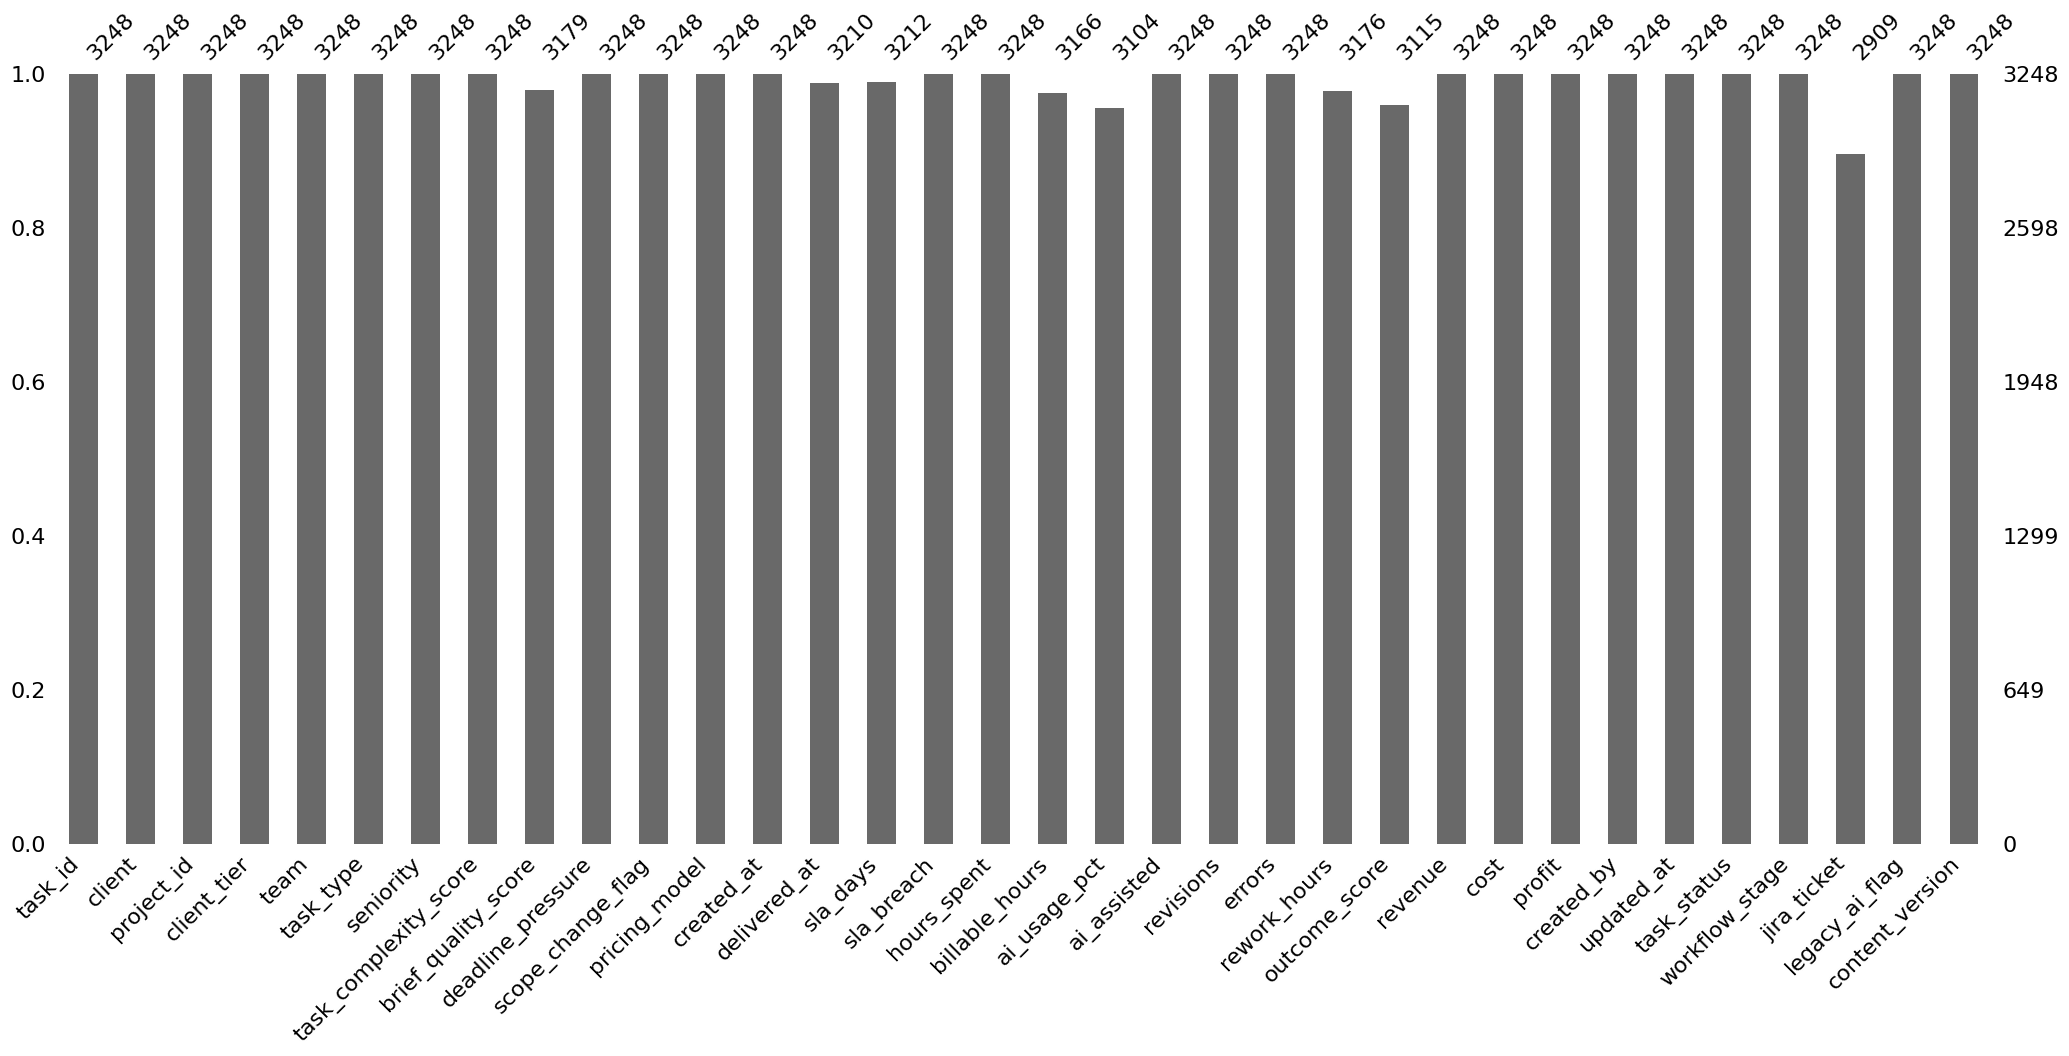

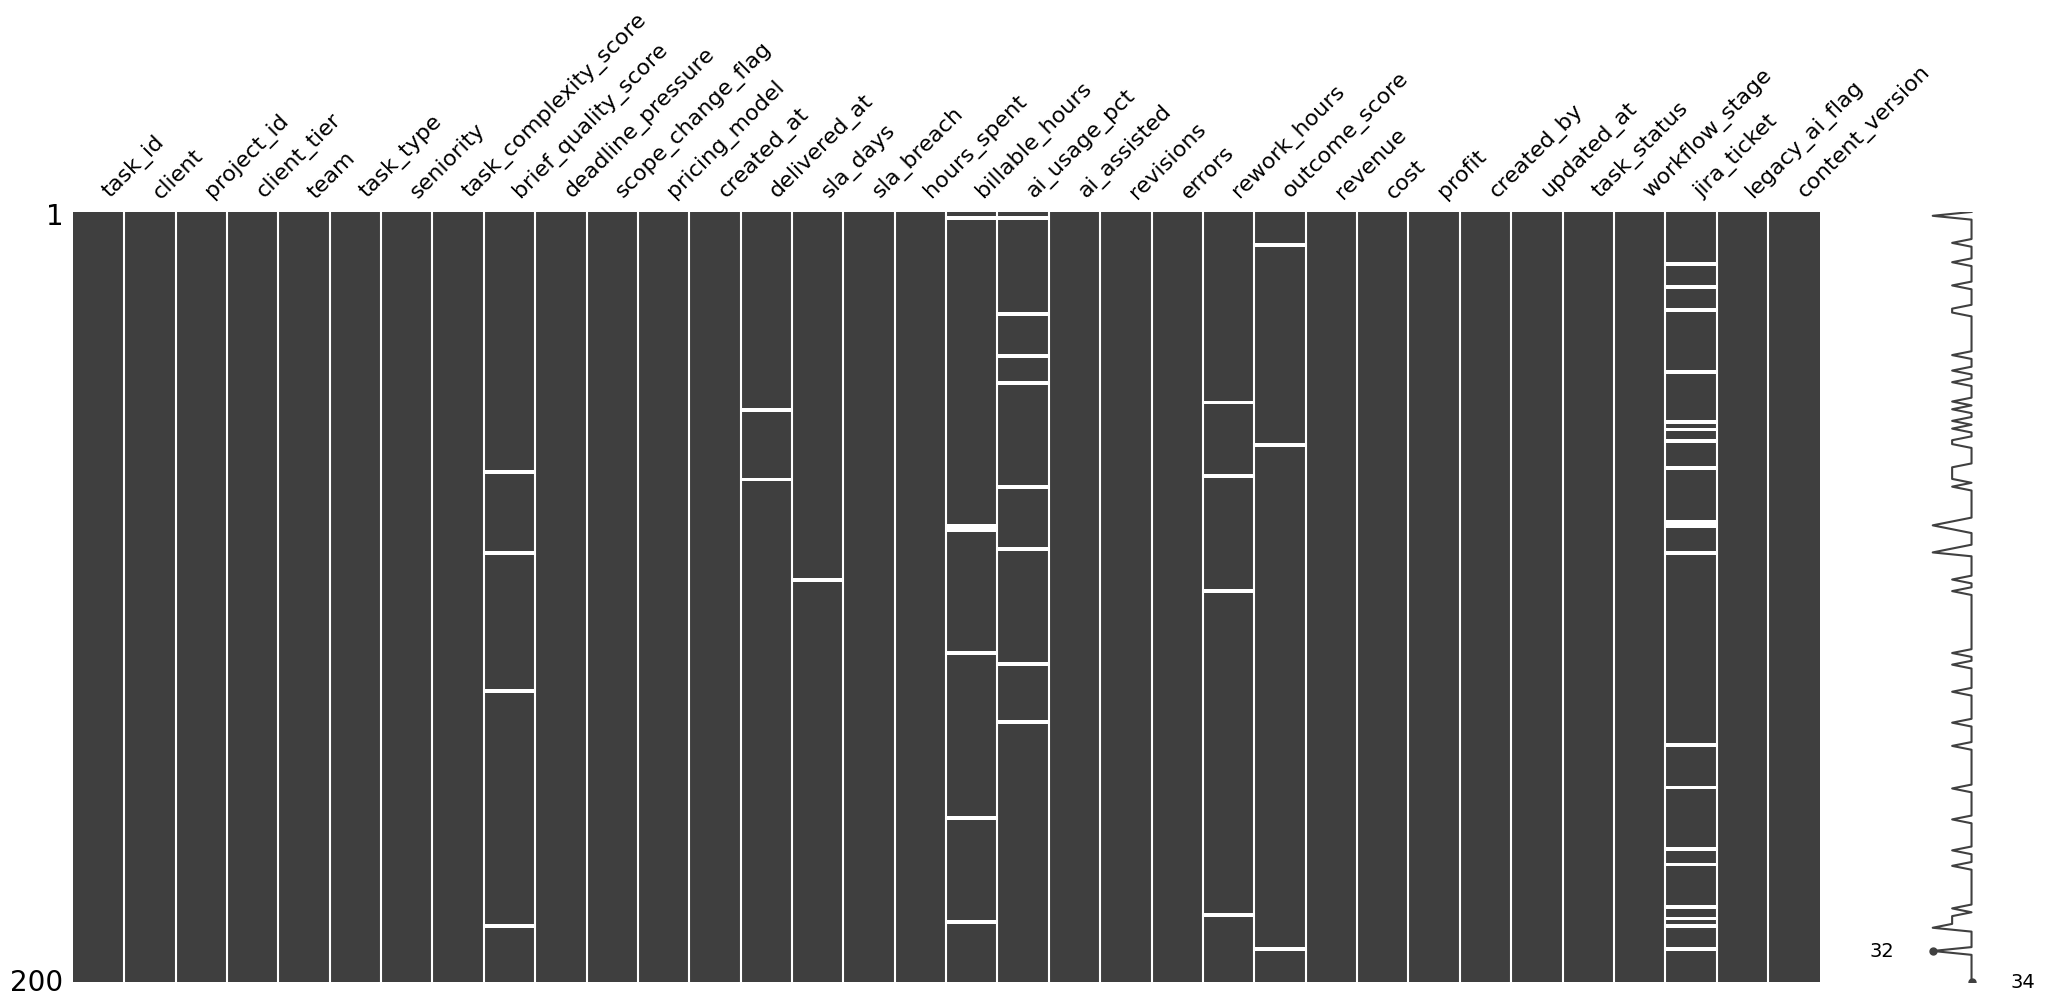

In [163]:
# visualization of columns that contain missing values
msno.bar(raw_df)
msno.matrix(raw_df.sample(200))

In [164]:
missing_percentage = (missing_values / raw_df.shape[0]) * 100
missing_percentage[missing_percentage > 0]

brief_quality_score     2.124384
delivered_at            1.169951
sla_days                1.108374
billable_hours          2.524631
ai_usage_pct            4.433498
rework_hours            2.216749
outcome_score           4.094828
jira_ticket            10.437192
dtype: float64

In [165]:
raw_df["client_tier"].value_counts()

# client tier is used to classify the "importance" in terms of value/revenues... of the different clients

client_tier
mid     1514
low      877
high     857
Name: count, dtype: int64

In [166]:
raw_df["project_id"].value_counts()


project_id
P028    77
P038    70
P021    64
P011    63
P060    62
        ..
P002    39
P051    39
P007    37
P048    37
P039    36
Name: count, Length: 64, dtype: int64

In [167]:
raw_df["task_status"].value_counts()

task_status
in_progress    1129
review          866
delivered       769
draft           183
archived        151
blocked         150
Name: count, dtype: int64

In [168]:
raw_df["content_version"].value_counts()

content_version
v1       926
v2       775
v3       667
final    560
v4       320
Name: count, dtype: int64

In [169]:
raw_df["workflow_stage"].value_counts()

workflow_stage
qa               687
client_review    664
finalized        643
briefing         640
execution        614
Name: count, dtype: int64

In [170]:
raw_df["team"].value_counts()

# team is used to classify the different teams working on the projects
# we can obsserve that there are some repetitions and errors so I need to fix them

raw_df["team"] = raw_df["team"].str.lower()
raw_df["team"] = raw_df["team"].str.strip()
raw_df["team"].value_counts()

# I need to convert the value "contennt" to "content" in the team name column
raw_df["team"] = raw_df["team"].replace("contennt", "content")
raw_df["team"] = raw_df["team"].replace("desgn", "design")
raw_df["team"].value_counts()

# We need to think if we wanna merge paid media with media or if we wanna keep them separate

team
content       835
media         813
design        798
seo           794
paid media      8
Name: count, dtype: int64

In [171]:
raw_df["task_type"].value_counts()

# we need to clean the task_type column as well
raw_df["task_type"] = raw_df["task_type"].str.lower()
raw_df["task_type"] = raw_df["task_type"].str.strip()

raw_df["task_type"].value_counts()
raw_df["task_type"] = raw_df["task_type"].replace("relese", "release")
raw_df["task_type"] = raw_df["task_type"].replace("release_task", "release")
raw_df["task_type"] = raw_df["task_type"].replace("dev_task", "dev")
raw_df["task_type"] = raw_df["task_type"].replace("ad_task", "ad")
raw_df["task_type"] = raw_df["task_type"].replace("article_task", "article")
raw_df["task_type"] = raw_df["task_type"].replace("artcle", "article")
raw_df["task_type"] = raw_df["task_type"].replace("repport", "report")
raw_df["task_type"] = raw_df["task_type"].replace("report_task", "report")
raw_df["task_type"] = raw_df["task_type"].replace("design_task", "design")
raw_df["task_type"] = raw_df["task_type"].replace("ticket_task", "ticket")
raw_df["task_type"] = raw_df["task_type"].replace("dev", "development")

raw_df["task_type"].value_counts()

# we have to decide how we wanna treat blog_article (if merge with article), paid_ad (if merge with ad) and support_ticket (if merge with ticket)
# we need also to think ho we wanna handle "creative" since they are only 5 obs

task_type
design            473
ticket            470
ad                470
report            466
article           465
development       446
release           443
creative            5
paid_ad             4
support_ticket      3
blog_article        3
Name: count, dtype: int64

In [172]:
raw_df["seniority"].value_counts()

seniority
mid       1296
junior    1190
senior     762
Name: count, dtype: int64

In [173]:
raw_df["task_complexity_score"].value_counts()

task_complexity_score
3    962
2    805
4    675
1    477
5    329
Name: count, dtype: int64

In [174]:
raw_df["brief_quality_score"].value_counts()
# as inspected before this columns contains nan values(2,12 % of the total observations)
raw_df["missing_flag"] = raw_df["brief_quality_score"].isna().astype(int)
raw_df.groupby("missing_flag").mean(numeric_only=True)

# An analysis comparing missing vs non missing observations showed that missing values are almost completely at random (MCAR)
# as they are associated with very little differences in variables such as task duration, SLA breach and scope changes.
# For this reason (+ for the fact that they are only 2,12% of the total observations), missing values were handled using median imputation
# combined with the creation of a binary indicator ("brief_quality_missing") to show if the differences were meaningful or not.

raw_df.drop(columns=["missing_flag"], inplace=True)

In [175]:
raw_df["brief_quality_score"] = raw_df["brief_quality_score"].fillna(raw_df["brief_quality_score"].median())

In [176]:
raw_df["deadline_pressure"].value_counts()

deadline_pressure
medium    1482
low        914
high       852
Name: count, dtype: int64

In [177]:
raw_df["scope_change_flag"].value_counts()  

#it may mean that the scope of the task has changed during its execution    

scope_change_flag
0    2796
1     452
Name: count, dtype: int64

In [178]:
raw_df.columns

Index(['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type',
       'seniority', 'task_complexity_score', 'brief_quality_score',
       'deadline_pressure', 'scope_change_flag', 'pricing_model', 'created_at',
       'delivered_at', 'sla_days', 'sla_breach', 'hours_spent',
       'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors',
       'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit',
       'created_by', 'updated_at', 'task_status', 'workflow_stage',
       'jira_ticket', 'legacy_ai_flag', 'content_version'],
      dtype='str')

In [179]:
raw_df["pricing_model"].value_counts()

pricing_model
hourly         1561
fixed          1227
value_based     460
Name: count, dtype: int64

In [180]:
raw_df["created_at"].value_counts()
#raw_df["created_at"].dtype
# I need to convert "created_at" to datetime since it's a str
raw_df["created_at"] = pd.to_datetime(raw_df["created_at"], errors="coerce")
raw_df["created_at"].head()

0   2025-11-20
1   2026-01-24
2   2025-09-16
3   2025-11-06
4   2026-05-02
Name: created_at, dtype: datetime64[us]

In [181]:
raw_df["delivered_at"].value_counts()
# I need to convert "delivered_at" to datetime since it's a str
raw_df["delivered_at"] = pd.to_datetime(raw_df["delivered_at"], errors="coerce")

# I need to handle nan values in this column since, as discovered before, they are about 1% of total obs in the column

In [182]:
missing_values = raw_df[raw_df["delivered_at"].isnull()]["task_status"].value_counts()
missing_values

task_status
delivered      13
in_progress    12
review          7
archived        4
blocked         1
draft           1
Name: count, dtype: int64

In [183]:
raw_df[raw_df["task_status"] != "delivered"]["delivered_at"].notna().sum()
# As we can see from the analysis above, there are observations with "delivered_at" not null but with "task_status" different from "delivered",
# so the missingness are true missing

np.int64(2454)

In [184]:
raw_df["sla_days"].value_counts()

sla_days
5.0     897
3.0     715
7.0     627
2.0     581
10.0    392
Name: count, dtype: int64

In [185]:
raw_df[raw_df["sla_days"].isna()]

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
137,T00137,Client_E,P034,low,media,article,mid,3,5.0,medium,...,1159.05,647.330000,511.720000,user_101,2025-08-20,delivered,execution,JIRA-36785,true,final
413,T00413,Client_B,P052,low,paid media,article,junior,3,2.0,medium,...,1053.54,700.740000,352.800000,user_004,2026-03-12,in_progress,finalized,JIRA-51749,false,v1
525,T00525,Client_E,P033,high,seo,article,mid,2,5.0,medium,...,1370.42,877.100000,493.320000,user_051,2026-04-19,review,qa,JIRA-71622,true,v1
645,T00645,Client_B,P003,high,media,article,senior,4,4.0,low,...,1827.77,1159.040000,668.730000,user_039,2025-10-01,in_progress,qa,JIRA-35913,false,v3
776,T00776,Client_B,P025,high,seo,ticket,mid,4,4.0,low,...,1148.38,426.560000,721.820000,user_073,2025-11-23,draft,client_review,JIRA-93809,false,final
801,T00801,Client_H,P029,high,design,article,senior,4,1.0,low,...,813.52,733.740000,79.780000,user_028,2025-12-22,in_progress,client_review,JIRA-43029,true,v3
895,T00895,Client_B,P026,high,design,design,senior,2,3.0,high,...,1076.52,1312.090000,-235.570000,user_036,2025-10-07,draft,execution,JIRA-52294,true,v1
939,T00939,Client_E,P011,high,seo,article,senior,3,3.0,low,...,1037.62,660.470000,377.150000,user_012,2025-11-25,delivered,briefing,JIRA-86046,true,v1
1056,T01056,Client_E,P007,high,design,creative,junior,5,4.0,medium,...,1101.94,696.010000,405.930000,user_108,2026-02-22,delivered,client_review,NaN,false,v1
1501,T01501,Client_A,P058,mid,content,ticket,junior,4,3.0,medium,...,797.66,661.630000,136.030000,user_036,2025-08-13,draft,qa,JIRA-45039,true,v1


In [186]:
# I can inpute sla_days missings with the median since the missings are completely at random
raw_df["sla_days"] = raw_df["sla_days"].fillna(raw_df["sla_days"].median())

In [187]:
raw_df["sla_breach"].value_counts()
# this column indicates if the time to complete the task (in sla_days) has been respected (0) or not (1)

sla_breach
0    1955
1    1293
Name: count, dtype: int64

In [188]:
raw_df["hours_spent"].value_counts()

hours_spent
9.850000      9
7.320000      8
6.080000      8
9.360000      7
9.750000      7
             ..
4.370000      1
13.650000     1
9.120000      1
0.040000      1
170.890419    1
Name: count, Length: 1640, dtype: int64

In [189]:
raw_df["billable_hours"].value_counts()

billable_hours
5.48     10
6.01      8
6.17      8
5.25      8
4.45      8
         ..
16.18     1
13.52     1
13.88     1
8.44      1
12.88     1
Name: count, Length: 1386, dtype: int64

In [190]:
raw_df[raw_df["billable_hours"].isna()]

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
55,T00055,Client_F,P057,low,seo,report,junior,3,3.0,medium,...,1024.79,292.57,732.22,user_068,2026-03-09,in_progress,qa,JIRA-92545,true,v4
105,T00105,Client_H,P063,mid,media,ad,mid,3,1.0,high,...,1588.92,472.46,1116.46,user_101,2026-02-19,review,finalized,NaN,false,v3
132,T00132,Client_F,P052,mid,content,development,mid,5,3.0,medium,...,1873.05,704.27,1168.78,user_052,2025-08-17,in_progress,finalized,JIRA-25836,unknown,v1
148,T00148,Client_C,P034,mid,content,design,junior,3,3.0,medium,...,230.11,404.81,-174.70,user_052,2026-01-22,review,briefing,JIRA-95347,true,v2
159,T00159,Client_C,P011,mid,content,development,mid,2,3.0,low,...,636.07,904.19,-268.12,user_027,2025-08-05,delivered,briefing,JIRA-38465,true,final
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,T02915,Client_G,P026,high,design,article,mid,4,4.0,medium,...,351.72,210.99,140.73,user_016,2026-04-24,review,finalized,JIRA-48283,false,v3
2946,T02946,Client_E,P018,low,design,development,mid,4,5.0,medium,...,1336.35,862.11,474.24,user_051,2025-09-01,delivered,client_review,JIRA-76475,false,v3
3044,T03044,Client_F,P052,mid,media,ad,mid,4,3.0,low,...,1380.61,446.61,934.00,user_100,2025-12-16,review,execution,JIRA-36479,unknown,v2
3079,T03079,Client_F,P039,low,seo,report,junior,2,3.0,medium,...,712.08,644.41,67.67,user_039,2026-05-13,review,finalized,JIRA-28940,true,final


In [191]:
raw_df[raw_df["billable_hours"].isna()][["task_status", "pricing_model", "hours_spent", "revenue", "cost", "profit"]].head(50)
raw_df["billable_hours"] = raw_df.groupby(["pricing_model", "task_type"])["billable_hours"].transform(lambda x: x.fillna(x.median()))

raw_df["billable_hours"] = raw_df["billable_hours"].fillna(raw_df["billable_hours"].median())

# Missing values in "billable_hours" were analyzed and found to be true missing data rather than non-billable tasks and as highlighted before only 2.52% of the column's values.
# A group-based median imputation (by pricing_model and task_type) was applied to preserve business structure, followed by a global median fallback for remaining cases (only one obs).

In [192]:
raw_df["ai_usage_pct"].value_counts()

ai_usage_pct
0.26    68
0.24    65
0.30    65
0.25    59
0.50    58
        ..
0.86     3
0.87     3
0.90     3
0.84     2
0.00     2
Name: count, Length: 92, dtype: int64

In [193]:
raw_df[raw_df["ai_usage_pct"].isna()]

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
15,T00015,Client_D,P008,mid,seo,development,senior,3,3.0,medium,...,1255.54,882.97,372.57,user_048,2026-02-01,in_progress,execution,JIRA-62159,false,v1
30,T00030,Client_B,P036,mid,content,development,junior,1,2.0,medium,...,983.45,618.27,365.18,user_011,2026-02-26,review,briefing,JIRA-49573,unknown,v1
31,T00031,Client_G,P044,low,design,release,mid,1,5.0,medium,...,734.72,573.31,161.41,user_031,2026-05-16,delivered,briefing,JIRA-73572,true,v1
63,T00063,Client_C,P025,low,seo,ad,senior,2,2.0,medium,...,515.00,570.32,-55.32,user_047,2025-12-17,delivered,finalized,NaN,true,final
136,T00136,Client_D,P052,mid,media,release,senior,3,4.0,medium,...,1528.37,1009.09,519.28,user_040,2026-03-02,in_progress,qa,JIRA-91180,true,v4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3118,T03118,Client_G,P016,mid,content,article,senior,3,3.0,medium,...,693.58,785.39,-91.81,user_075,2026-04-27,in_progress,qa,JIRA-20769,unknown,v1
3192,T03192,Client_O,P042,low,media,ad,mid,3,3.0,low,...,1424.81,970.07,454.74,user_087,2026-03-23,review,finalized,JIRA-25454,true,v1
3197,T03197,Client_G,P024,mid,design,design,senior,3,3.0,medium,...,1100.02,751.91,348.11,user_017,2025-12-21,review,finalized,JIRA-62753,true,v1
3217,T01740,Client_S,P011,mid,seo,release,junior,4,3.0,high,...,1703.55,1702.09,1.46,user_040,2026-02-13,delivered,execution,JIRA-25057,true,v3


In [194]:
raw_df[raw_df["ai_usage_pct"].isna()][[ "legacy_ai_flag","content_version"]].head(50)

,legacy_ai_flag,content_version
15,false,v1
30,unknown,v1
31,true,v1
63,true,final
136,true,v4
139,true,v1
142,false,v3
160,false,v2
166,true,v2
218,true,v3


In [195]:
raw_df[raw_df["legacy_ai_flag"] == "true"]["ai_usage_pct"].describe()
# An analysis of "ai_usage_pct" within legacy tasks showed a median usage of 0.34%, indicating that AI was actively used even in legacy data.
# Therefore, missing values do not represent absence of AI usage but rather missing information.

count    1381.000000
mean        0.365243
std         0.202176
min         0.010000
25%         0.200000
50%         0.340000
75%         0.510000
max         0.930000
Name: ai_usage_pct, dtype: float64

In [196]:
raw_df.groupby("legacy_ai_flag")["ai_usage_pct"].apply(lambda x: x.isna().mean())

# An analysis of missing values in 'ai_usage_pct' (4.5%) showed no significant differences across 'legacy_ai_flag' categories,
# indicating that missingness is not related to legacy system usage. For this reason I can inpute using the median.

raw_df["ai_usage_pct"] = raw_df["ai_usage_pct"].fillna(raw_df["ai_usage_pct"].median())

In [197]:
raw_df["ai_assisted"].value_counts()

ai_assisted
True     2561
False     687
Name: count, dtype: int64

In [198]:
raw_df["revisions"].value_counts()

revisions
2     686
3     666
1     543
4     530
5     340
6     179
0     175
7      88
8      28
9       9
10      3
11      1
Name: count, dtype: int64

In [199]:
raw_df["errors"].value_counts()
raw_df["errors"].describe()

count    3248.000000
mean        1.014163
std         1.042868
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: errors, dtype: float64

In [200]:
raw_df["rework_hours"].value_counts()

rework_hours
0.000000    271
1.170000     18
1.530000     18
1.200000     17
1.390000     17
           ... 
9.550000      1
9.810000      1
7.140000      1
5.583385      1
9.123913      1
Name: count, Length: 646, dtype: int64

In [201]:
raw_df[raw_df["rework_hours"].isna()][["errors", "revisions","task_status", "outcome_score"]].head(50)

,errors,revisions,task_status,outcome_score
47,1,3,in_progress,77.98
82,0,2,in_progress,68.17
89,2,4,delivered,55.63
138,0,4,review,71.45
158,0,3,delivered,86.61
160,0,4,in_progress,75.92
176,4,1,in_progress,79.97
203,1,0,delivered,43.72
219,0,7,delivered,73.94
221,1,1,delivered,55.59


In [202]:
raw_df[raw_df["errors"] == 0]["rework_hours"].describe()

count    1203.000000
mean        2.359997
std         3.387206
min         0.000000
25%         1.040000
50%         1.660000
75%         2.770000
max        57.517012
Name: rework_hours, dtype: float64

In [203]:
raw_df[raw_df["errors"] == 0]["rework_hours"].describe()
raw_df[raw_df["revisions"] == 0]["rework_hours"].describe()

count    168.000000
mean       1.782202
std        1.338072
min        0.000000
25%        0.935000
50%        1.485000
75%        2.297500
max        8.310000
Name: rework_hougit add src/main.ipynbrs, dtype: float64

In [204]:
raw_df["rework_hours"] = raw_df["rework_hours"].fillna(raw_df["rework_hours"].median())

# since missing "rework_hours" represent only 2,2% of the total data and "rework_hours" are present when no errors/revisions are made, missing values cannot be interpreted as 0.
# For these reasons they were treated as true missing data

In [205]:
raw_df["outcome_score"].value_counts()
raw_df["outcome_score"].describe()

count    3115.000000
mean       68.856918
std        12.642211
min         9.000000
25%        60.870000
50%        69.400000
75%        77.610000
max       100.000000
Name: outcome_score, dtype: float64

In [206]:
raw_df.groupby("task_status")["outcome_score"].describe()
raw_df.groupby("task_status")["workflow_stage"].describe()
raw_df[raw_df["outcome_score"].isna()][["task_status", "workflow_stage", "delivered_at"]].head(50)

# since outcome_score does not depend on task_status or workflow_stage, we can use the overall median
raw_df["outcome_score"] = raw_df["outcome_score"].fillna(raw_df["outcome_score"].median())

In [207]:
raw_df["revenue"].value_counts()
raw_df["revenue"].describe()

count     3248.000000
mean      1120.571260
std        841.649433
min         45.000000
25%        646.312500
50%        966.430000
75%       1364.700000
max      14927.204324
Name: revenue, dtype: float64

In [208]:
raw_df["cost"].value_counts()
raw_df["cost"].describe()

count    3248.000000
mean      771.308146
std       584.269354
min        77.850000
25%       440.805000
50%       649.065000
75%       941.145000
max      9409.639511
Name: cost, dtype: float64

In [209]:
raw_df["profit"].describe()

# negative values for profit indicates in what tasks the firm has lost money.

count     3248.000000
mean       349.263114
std        888.072715
min      -8510.549511
25%         -2.610000
50%        254.645000
75%        590.400000
max      14006.644324
Name: profit, dtype: float64

In [210]:
raw_df["created_by"].value_counts()
raw_df["created_by"].describe()

count         3248
unique         119
top       user_026
freq            44
Name: created_by, dtype: object

In [211]:
# I need to convert the column "updated_at" to datetime
raw_df["updated_at"] = pd.to_datetime(raw_df["updated_at"], errors="coerce")
raw_df["updated_at"].head()

0   2025-11-28
1   2026-01-26
2   2025-09-17
3   2025-11-12
4   2026-05-09
Name: updated_at, dtype: datetime64[us]

In [212]:
raw_df["task_status"].value_counts()

task_status
in_progress    1129
review          866
delivered       769
draft           183
archived        151
blocked         150
Name: count, dtype: int64

In [213]:
raw_df["workflow_stage"].value_counts()

workflow_stage
qa               687
client_review    664
finalized        643
briefing         640
execution        614
Name: count, dtype: int64

In [214]:
# The "jira_ticket" variable represents a unique identifier linking each task to its corresponding record in the Jira system.
# Since it does not carry predictive information, it was excluded from the analysis.
raw_df["jira_ticket"].value_counts()

# The 'jira_ticket' column contains approximately 10% missing values, representing tasks not tracked in the Jira system.
# As this variable is an identifier and does not provide predictive information, it was excluded from further analysis.

jira_ticket
JIRA-53111    2
JIRA-67759    2
JIRA-38743    2
JIRA-62438    2
JIRA-36863    2
             ..
JIRA-42947    1
JIRA-90491    1
JIRA-19154    1
JIRA-32851    1
JIRA-39958    1
Name: count, Length: 2868, dtype: int64

In [215]:
raw_df["legacy_ai_flag"].value_counts()

legacy_ai_flag
false      1458
true       1451
unknown     339
Name: count, dtype: int64

In [216]:
raw_df["content_version"].value_counts()

content_version
v1       926
v2       775
v3       667
final    560
v4       320
Name: count, dtype: int64

In [217]:
# checking if there are duplicated rows
print(raw_df.duplicated().sum())

0


In [218]:
missing_values = raw_df.isnull().sum()
missing_values[missing_values > 0]

delivered_at     38
jira_ticket     339
dtype: int64

In [219]:
# only for numerical columns 
raw_df.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,created_at,delivered_at,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit,updated_at
count,3248.000000,3248.000000,3248.000000,3248,3210,3248.000000,3248.000000,3248.00000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000,3248
mean,2.868842,3.179495,0.139163,2025-12-11 14:42:42.561576,2025-12-16 00:10:45.981308,5.012623,0.398091,13.05551,8.417523,0.360754,3.007697,1.014163,2.423632,68.879156,1120.571260,771.308146,349.263114,2025-12-16 02:34:17.142857
min,1.000000,1.000000,0.000000,2025-07-01 00:00:00,2025-07-03 00:00:00,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511,2025-07-01 00:00:00
25%,2.000000,2.000000,0.000000,2025-09-21 00:00:00,2025-09-25 00:00:00,3.000000,0.000000,7.91000,5.117500,0.210000,2.000000,0.000000,1.120000,61.282500,646.312500,440.805000,-2.610000,2025-09-24 18:00:00
50%,3.000000,3.000000,0.000000,2025-12-14 00:00:00,2025-12-18 00:00:00,5.000000,0.000000,11.11500,7.590000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000,2025-12-19 00:00:00
75%,4.000000,4.000000,0.000000,2026-03-03 00:00:00,2026-03-07 00:00:00,7.000000,1.000000,15.34500,10.562500,0.500000,4.000000,2.000000,2.920000,77.222500,1364.700000,941.145000,590.400000,2026-03-06 06:00:00
max,5.000000,5.000000,1.000000,2026-05-26 00:00:00,2026-06-02 00:00:00,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324,2026-06-03 00:00:00
std,1.196459,1.199060,0.346169,NaN,NaN,2.506320,0.489580,11.55750,4.729564,0.194971,1.804829,1.042868,2.880443,12.381054,841.649433,584.269354,888.072715,NaN


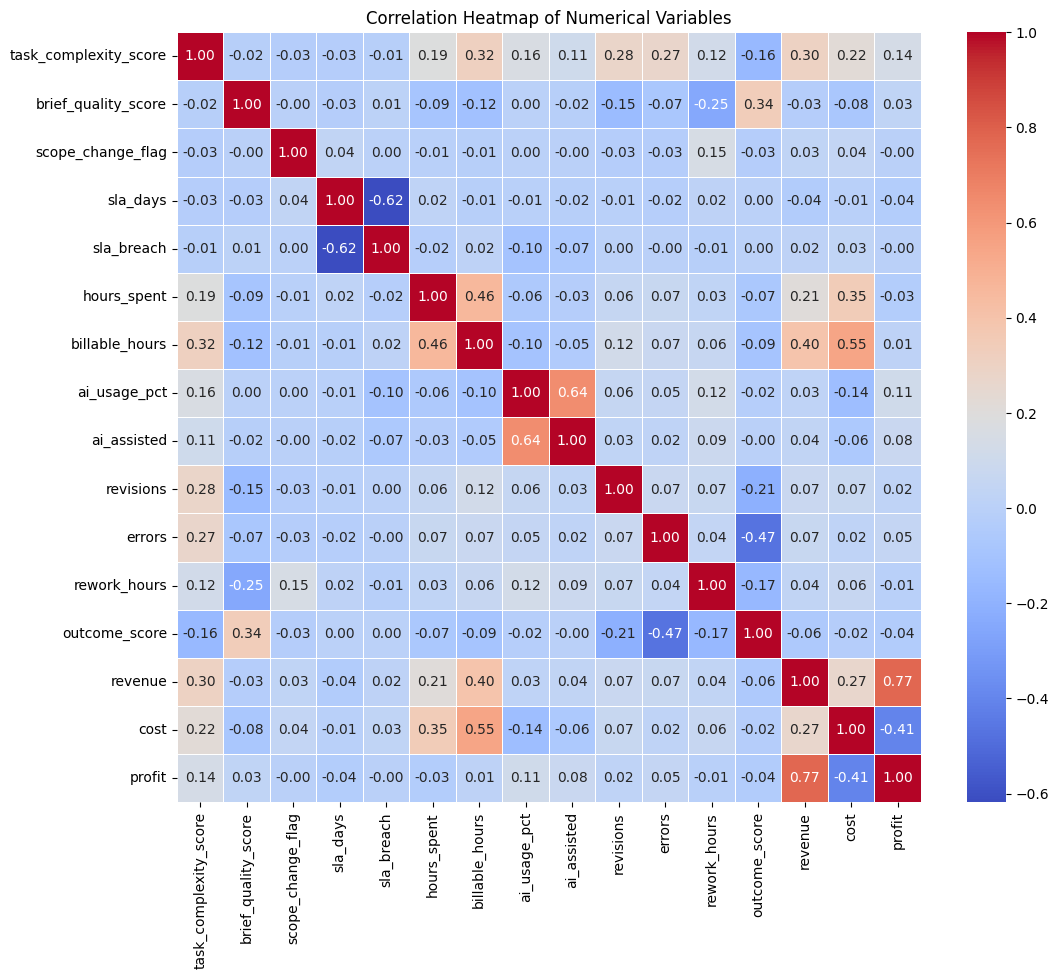

In [220]:
#heatmap of correlation between numerical variables
plt.figure(figsize=(12, 10))
sns.heatmap(raw_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

#the most correlated variables are billable_hours and cost (0.55), ai_usage_pct and ai_assisted (0.64) and revenue and profit (0.77)
#while sla_days and sla_breach are negatively correlated (-0.62) and also error and outcome_score(-0.47)but also cost and profit are negative correlated (-0.41)

In [221]:
num_cols = raw_df.select_dtypes(include=np.number).columns.tolist()
num_cols

['task_complexity_score',
 'brief_quality_score',
 'scope_change_flag',
 'sla_days',
 'sla_breach',
 'hours_spent',
 'billable_hours',
 'ai_usage_pct',
 'revisions',
 'errors',
 'rework_hours',
 'outcome_score',
 'revenue',
 'cost',
 'profit']

Distribution observations:
- The variables hours_spent, billable_hours, rework_hours, revenue, and cost
show strong right-skewness with obvious outliers.
A log transformation may be necessary before modeling.
- scope_change_flag and sla_breach are binary and unbalanced.
- outcome_score has an approximately left-normal distribution,
suitable as a target variable.
- profit has a bimodal distribution with both positive and negative values,
suggesting the existence of structurally different task segments.

In [222]:
cat_cols = ["team", "task_type", "seniority", "task_status", 
            "workflow_stage", "client_tier", "pricing_model", 
            "deadline_pressure", "ai_assisted", "legacy_ai_flag",
            "scope_change_flag", "content_version"]

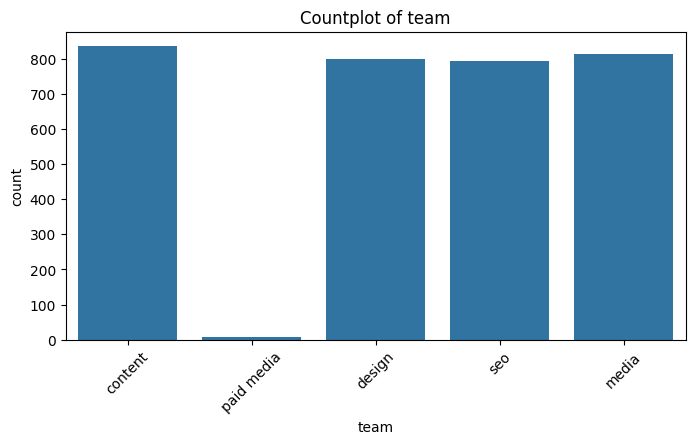

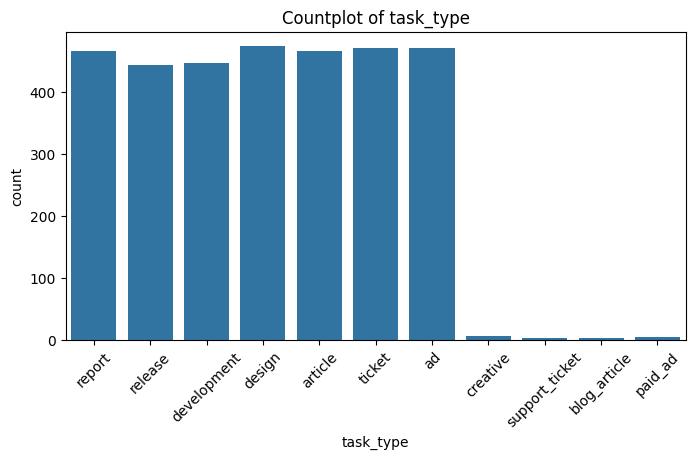

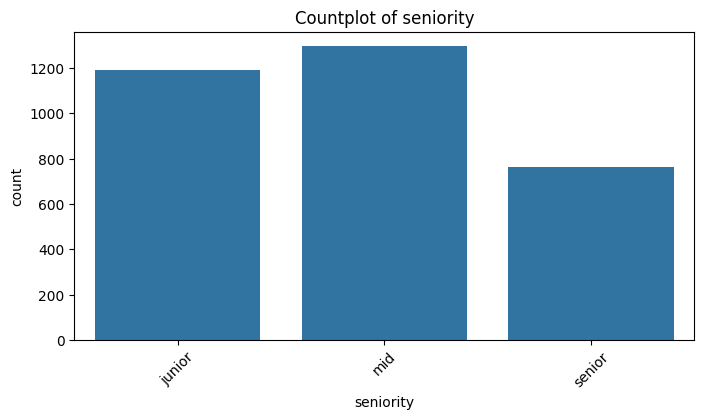

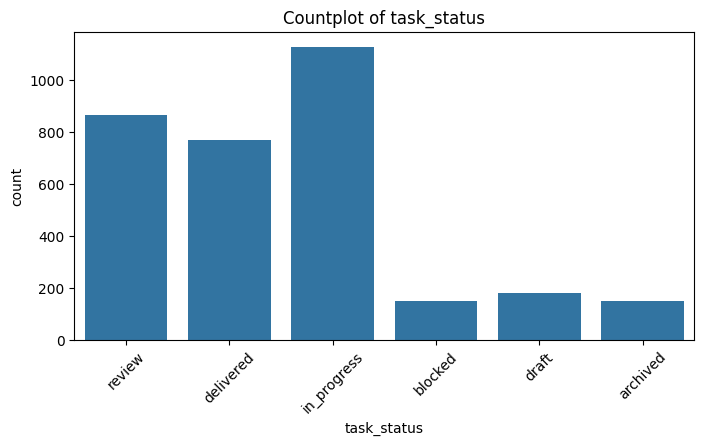

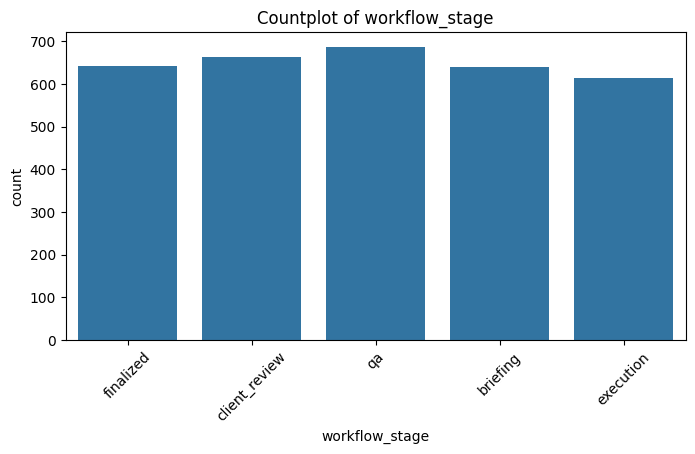

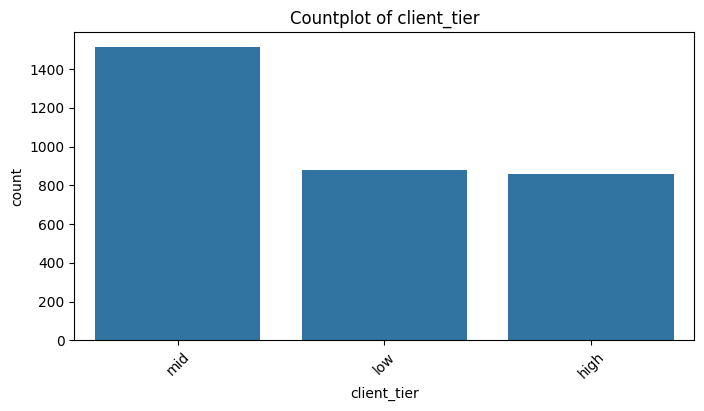

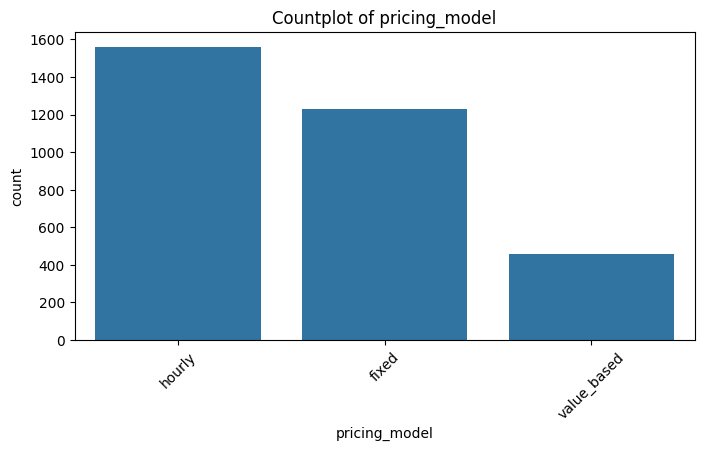

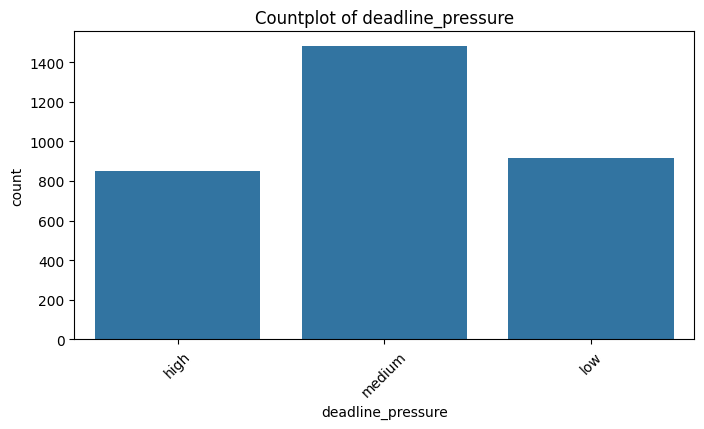

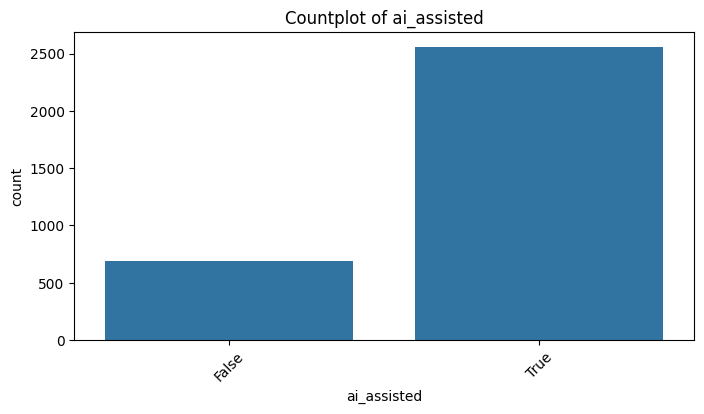

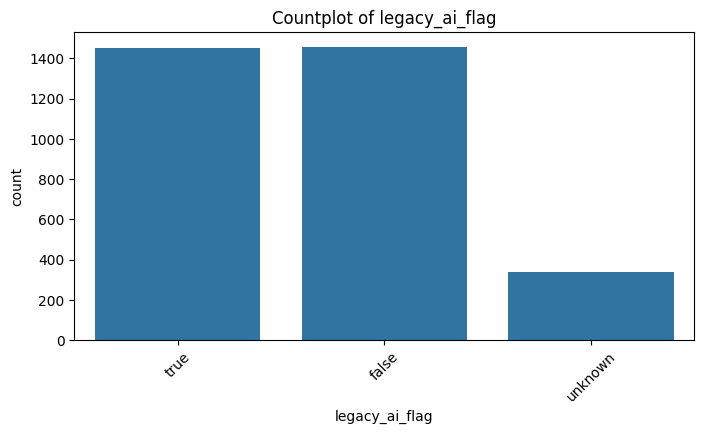

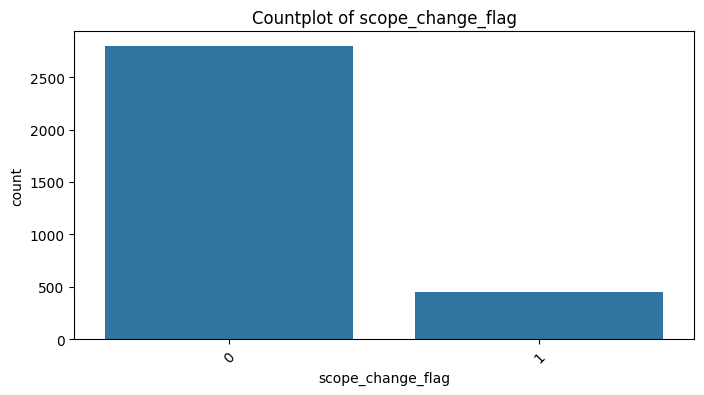

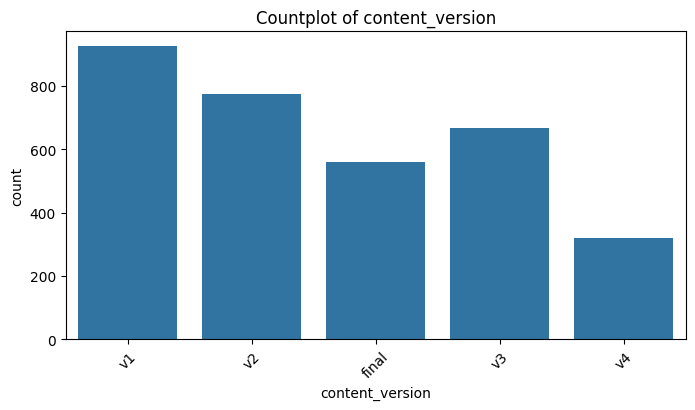

In [223]:
#countplot for categorical variables
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=raw_df, x=col)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

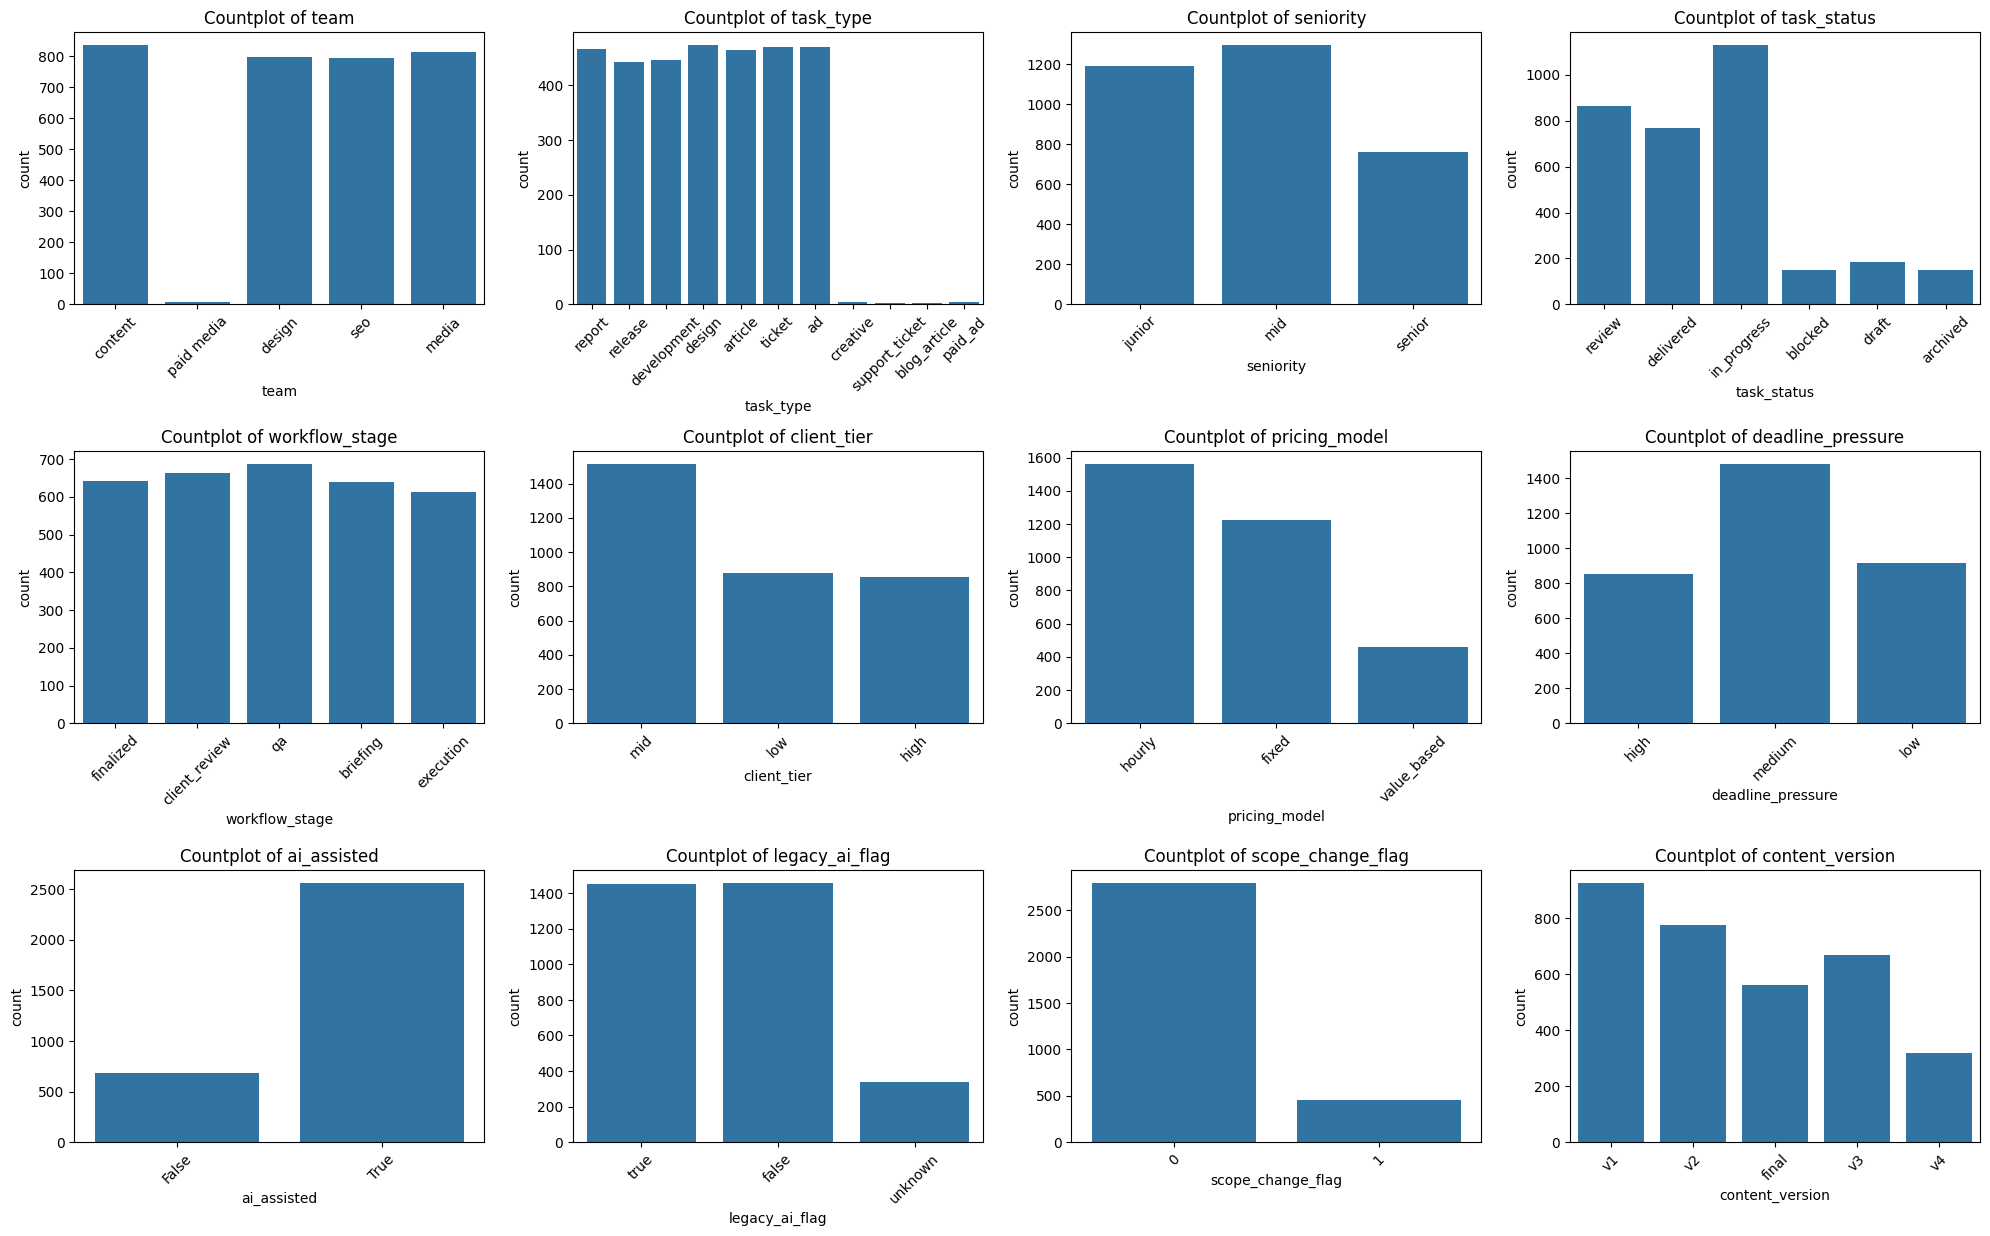

In [224]:
#only an image with all this plots together
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.countplot(data=raw_df, x=col)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)     
plt.tight_layout()
plt.show()

TEAM: we have to decide if we want to merge paid media(less observation) with media 


TASK_TYPE: decide whether to merge the categories with fewer observations with the more substantial ones


SENIOTIRY : Unbalanced distribution: significantly more junior and mid-level managers than senior managers. This is normal in an agency, but it must be taken into account in the analysis to avoid over- or underestimating the impact of seniority.




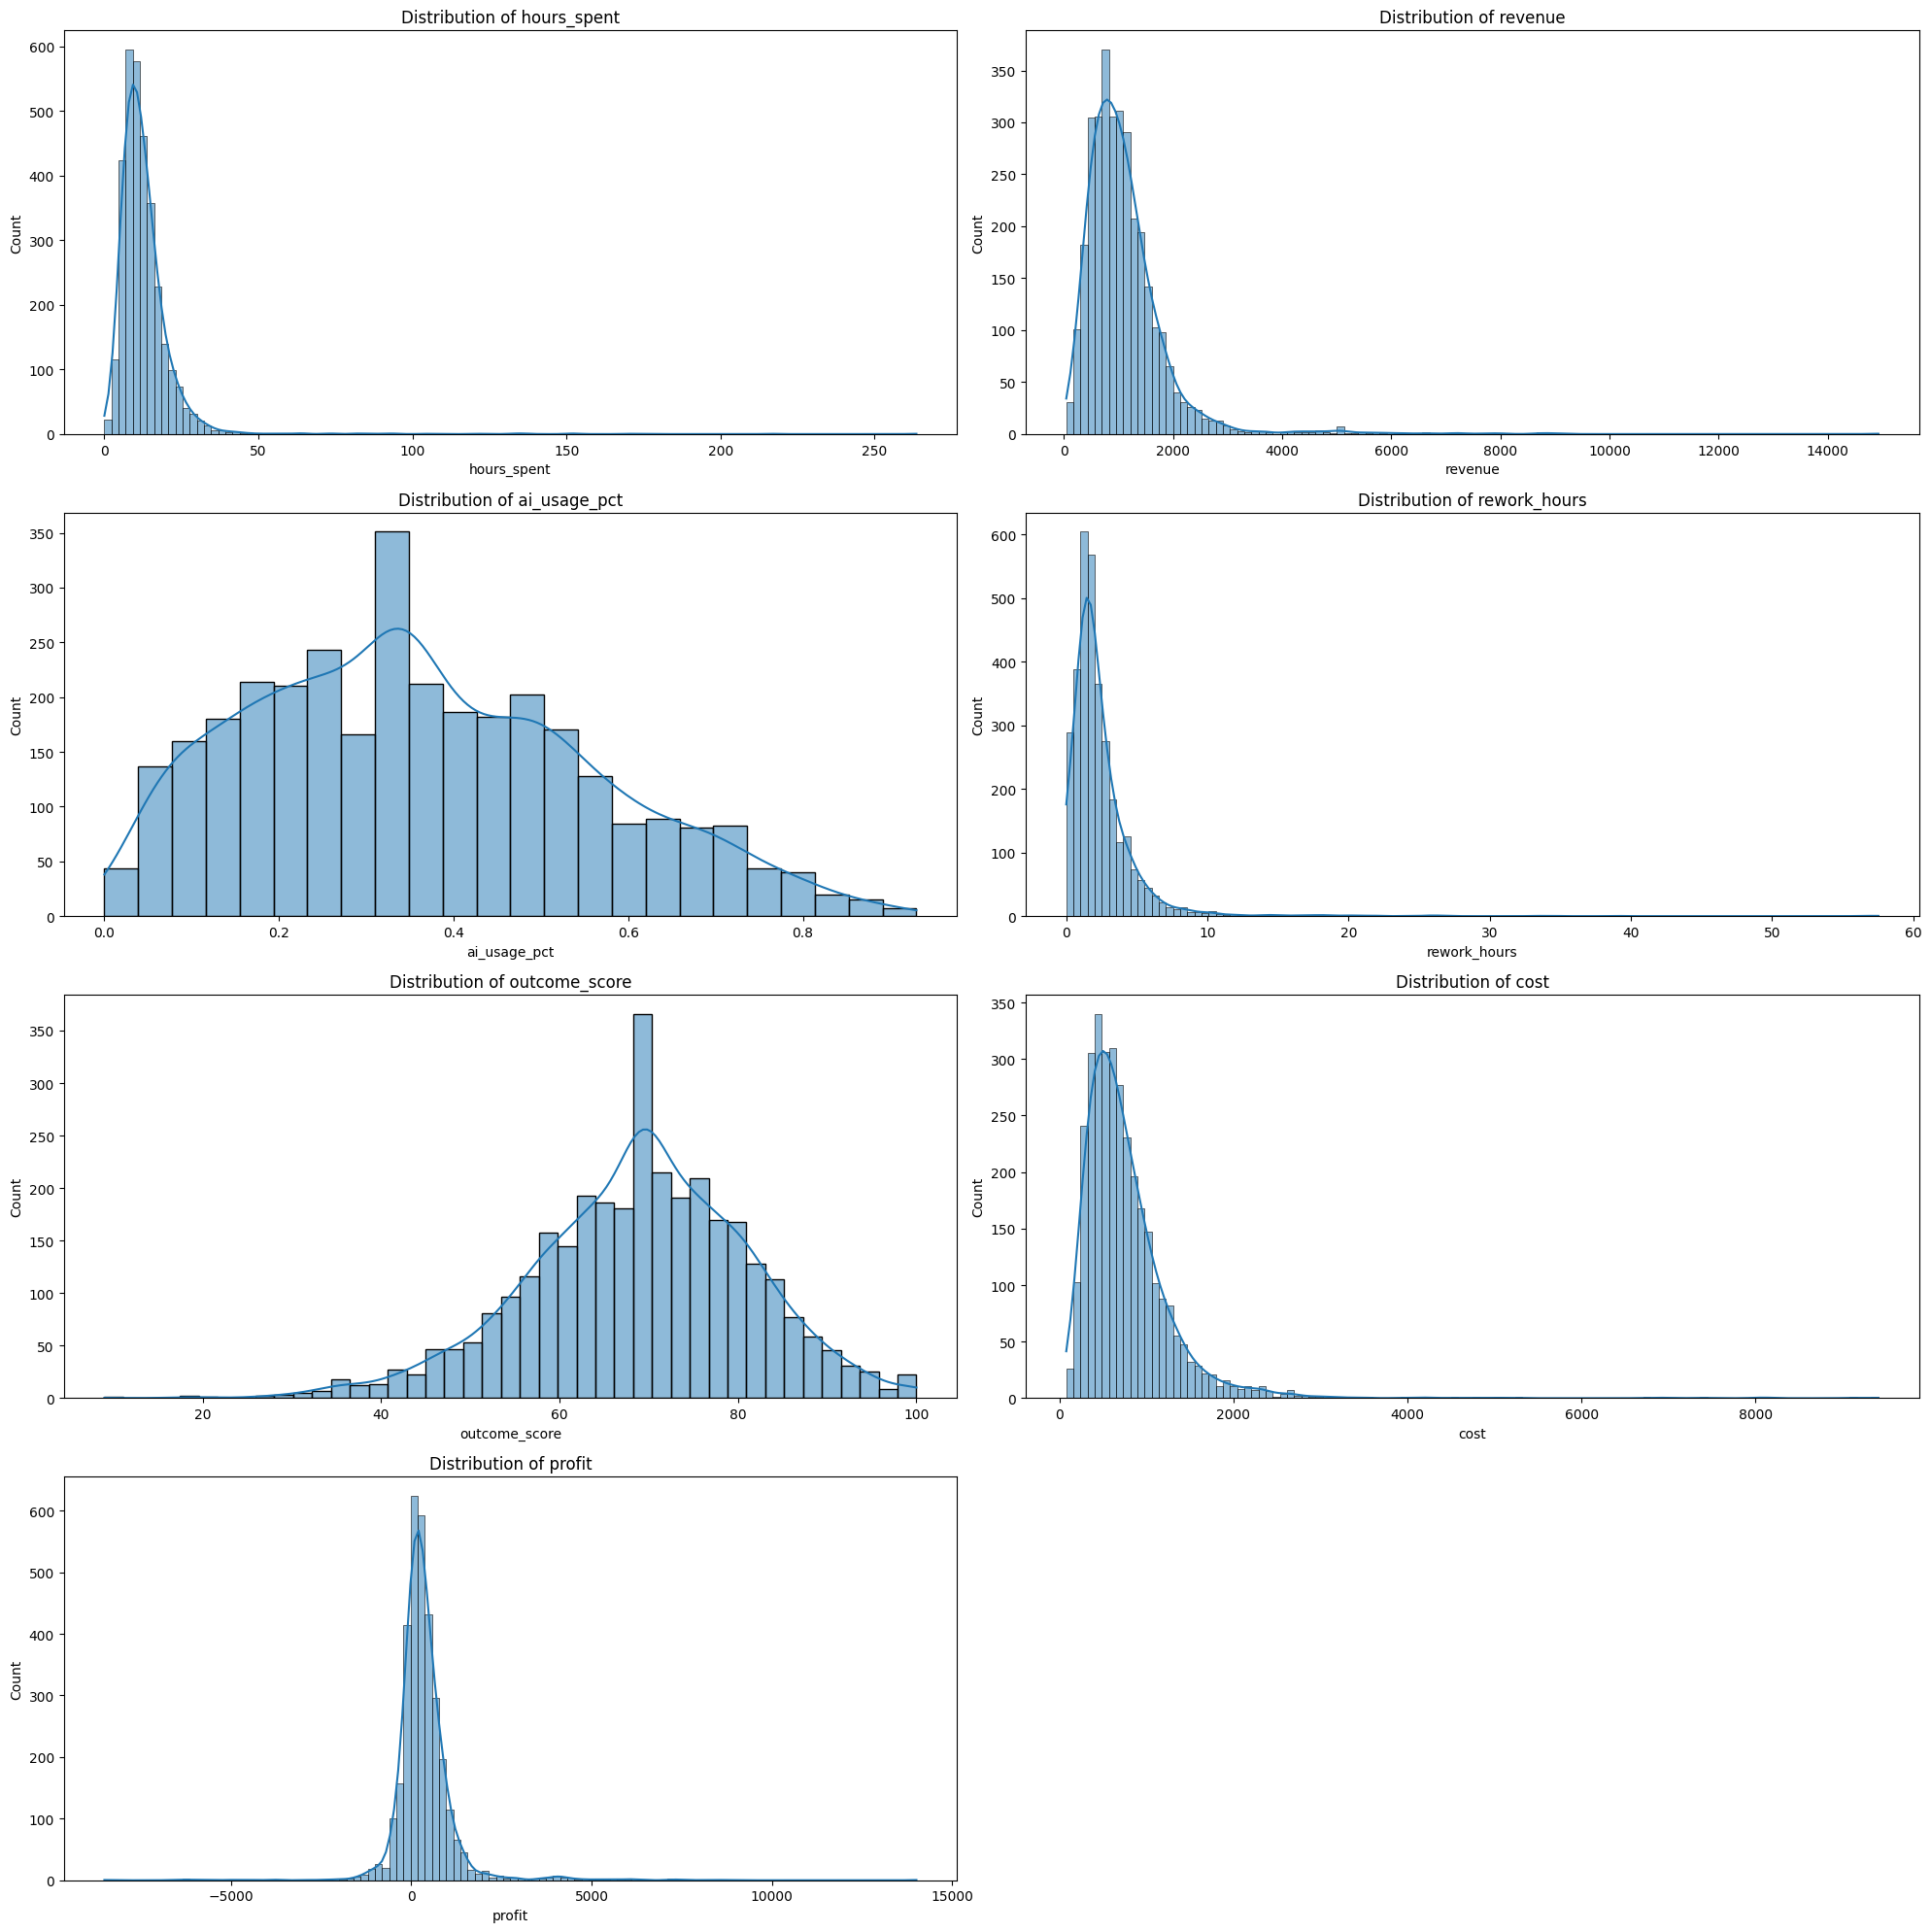

In [225]:
#distribution of hours_spent, revenue, ai_usage_pct, rework_hours, outcome_score, cost and profit
plt.figure(figsize=(20, 20))
cols_to_plot = ["hours_spent", "revenue", "ai_usage_pct", "rework_hours", "outcome_score", "cost", "profit"]
for i, col in enumerate(cols_to_plot):
    plt.subplot(4, 2, i + 1)
    sns.histplot(raw_df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

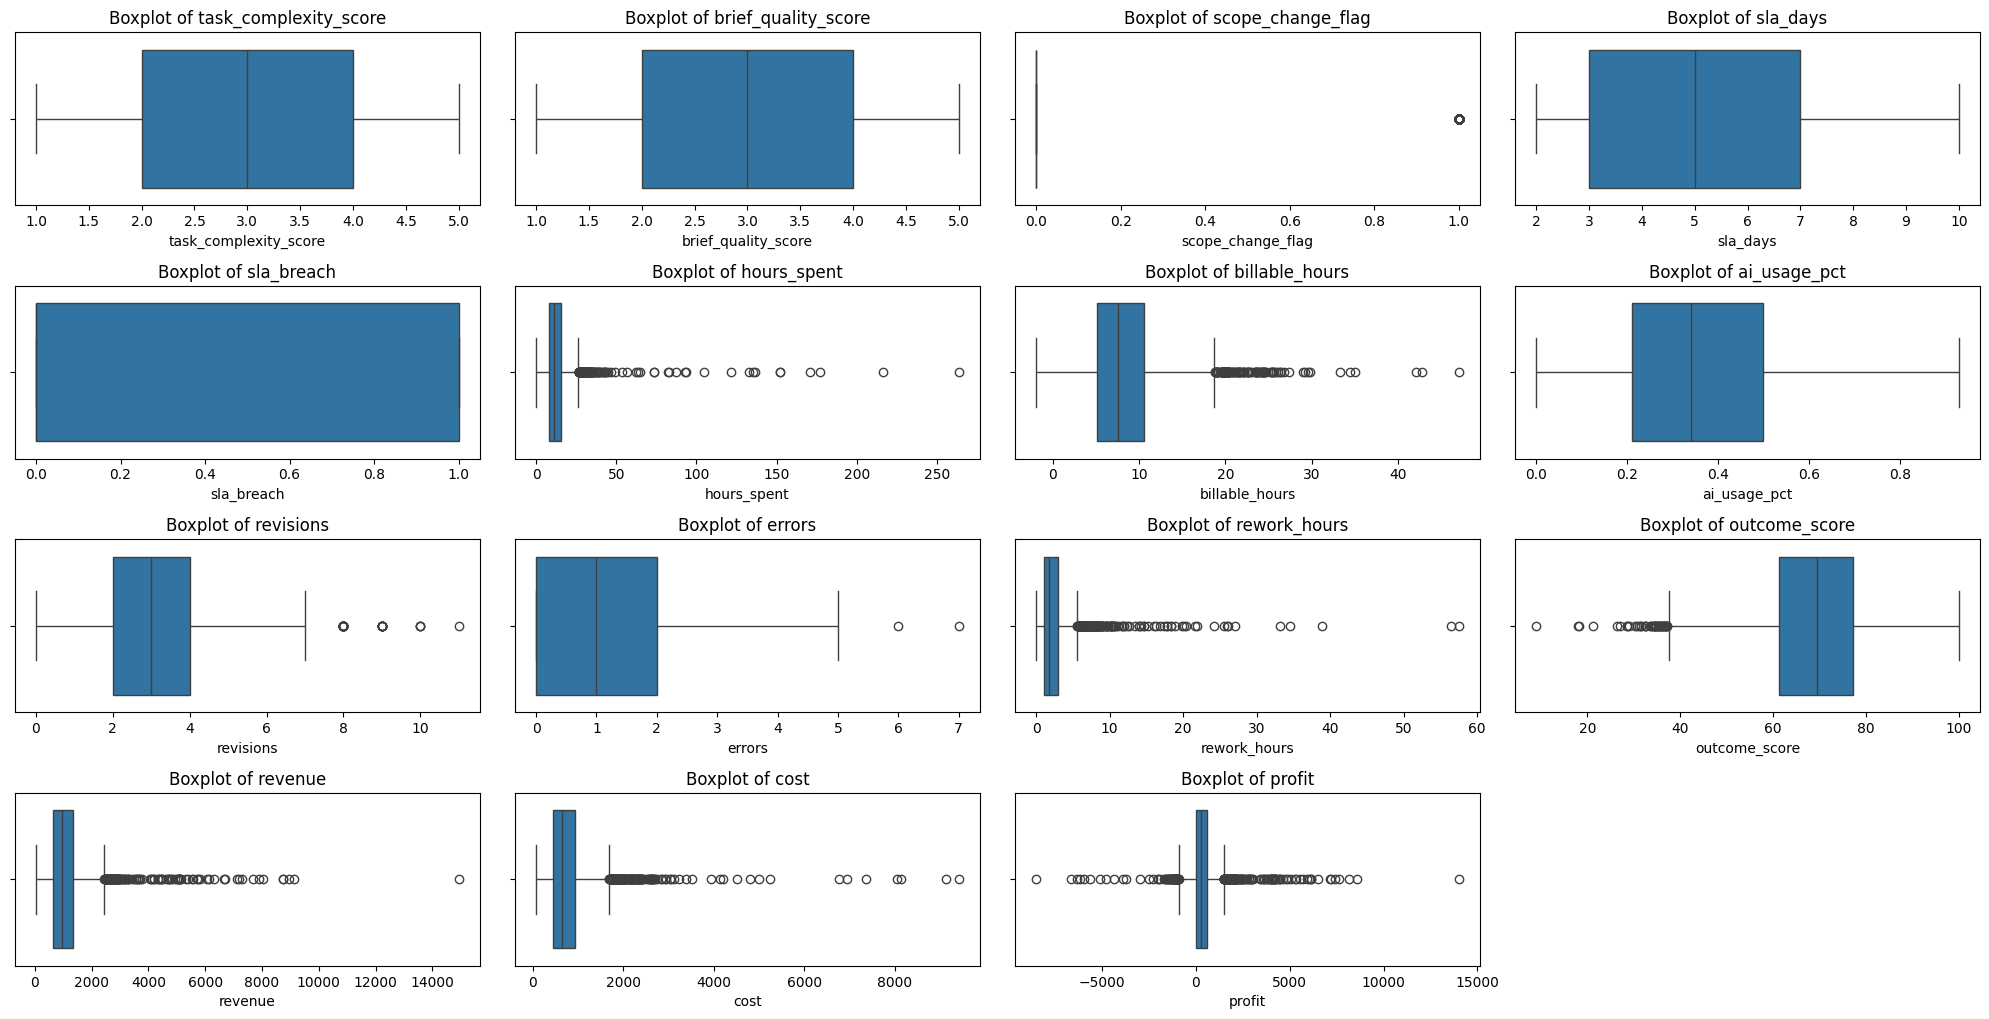

In [228]:
#boxplot for numerical columns 
plt.figure(figsize=(20, 20))
for i, col in enumerate(num_cols):
    plt.subplot(8, 4, i + 1)
    sns.boxplot(x=raw_df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

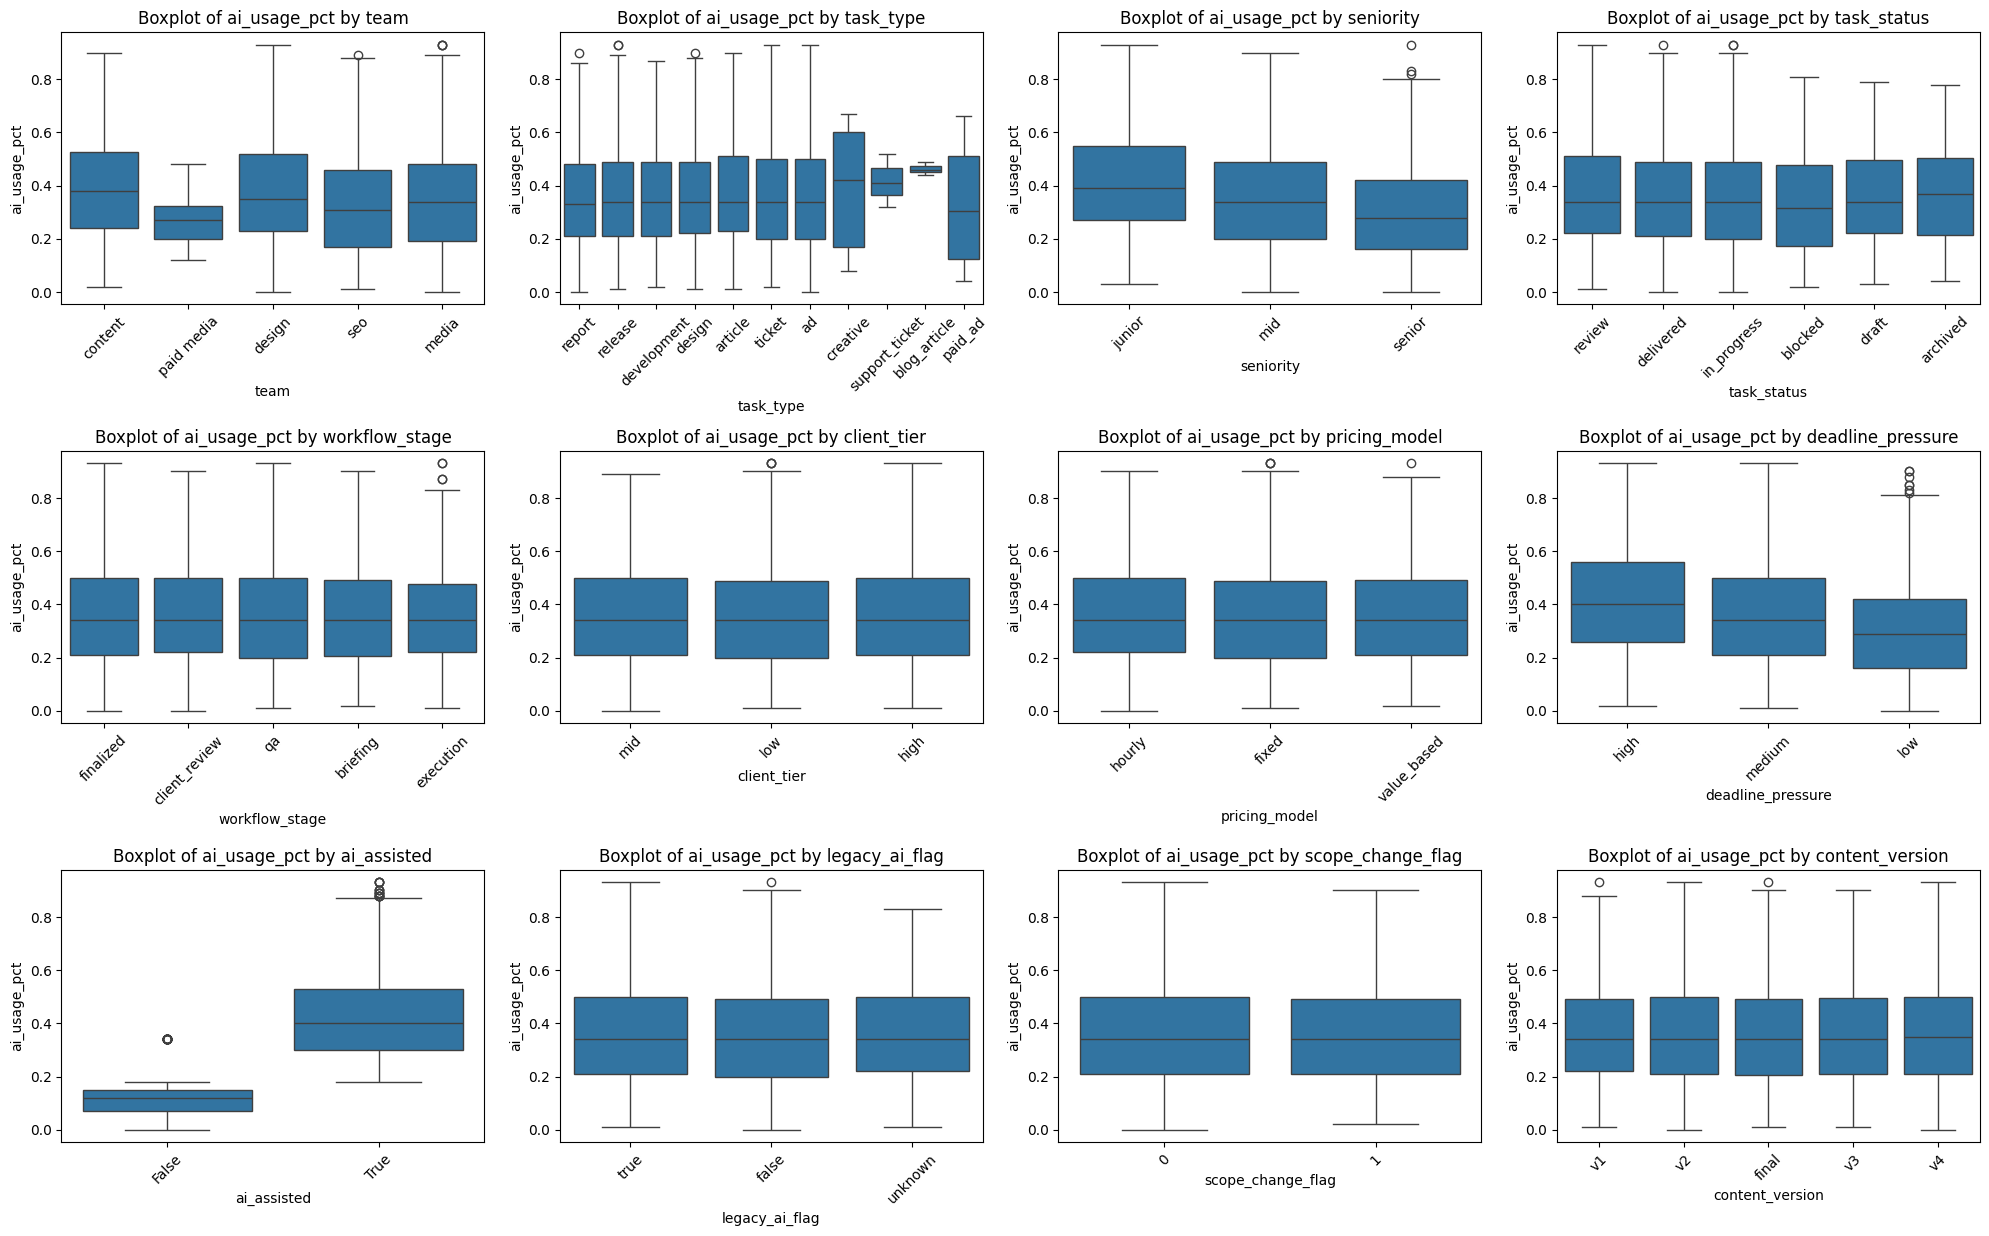

In [230]:
#boxplot for categorical variables
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(x=raw_df[col], y=raw_df["ai_usage_pct"])
    plt.title(f"Boxplot of ai_usage_pct by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

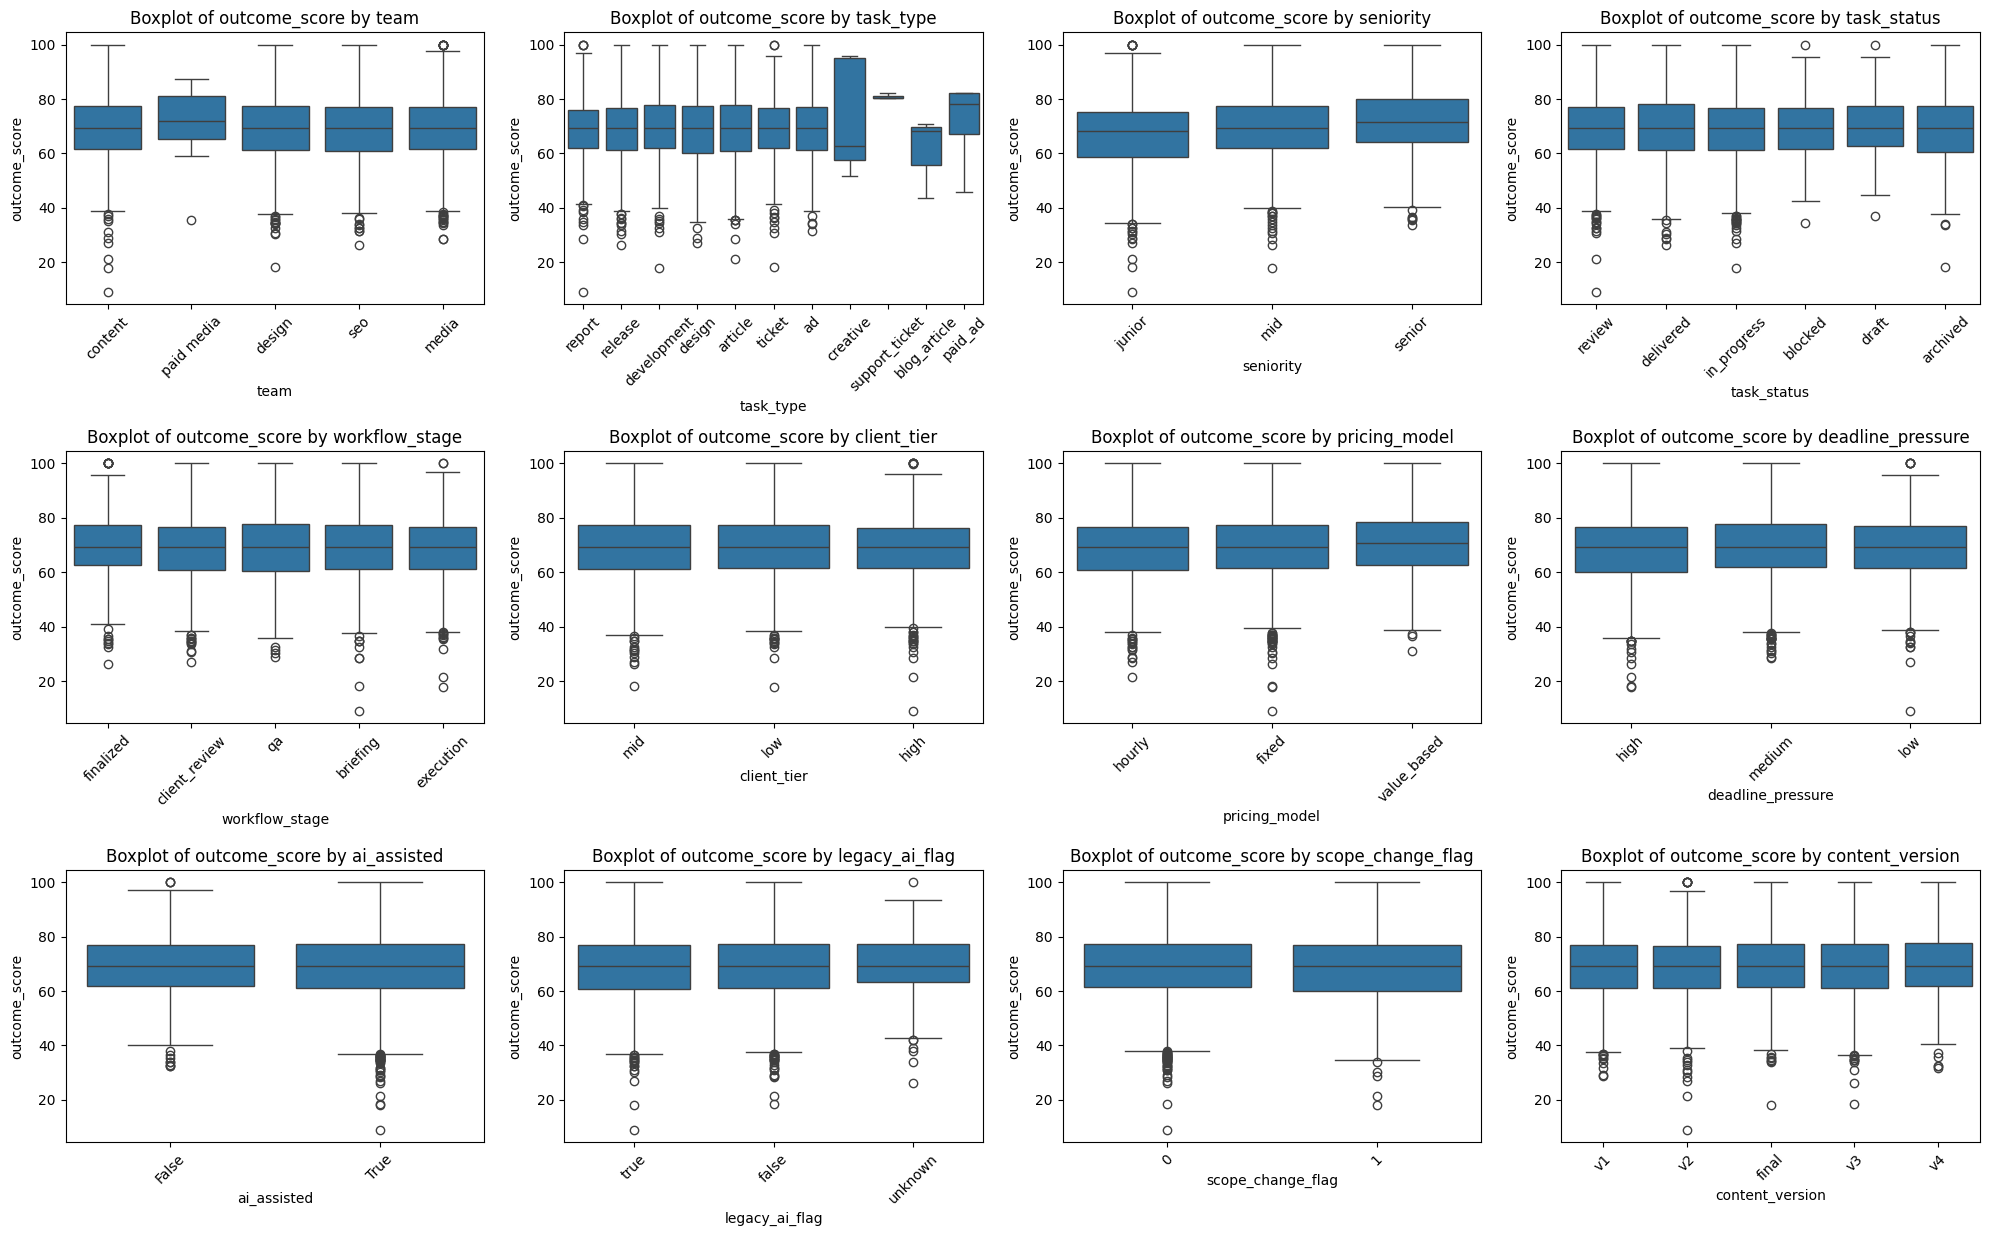

In [233]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(x=raw_df[col], y=raw_df["outcome_score"])
    plt.title(f"Boxplot of outcome_score by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

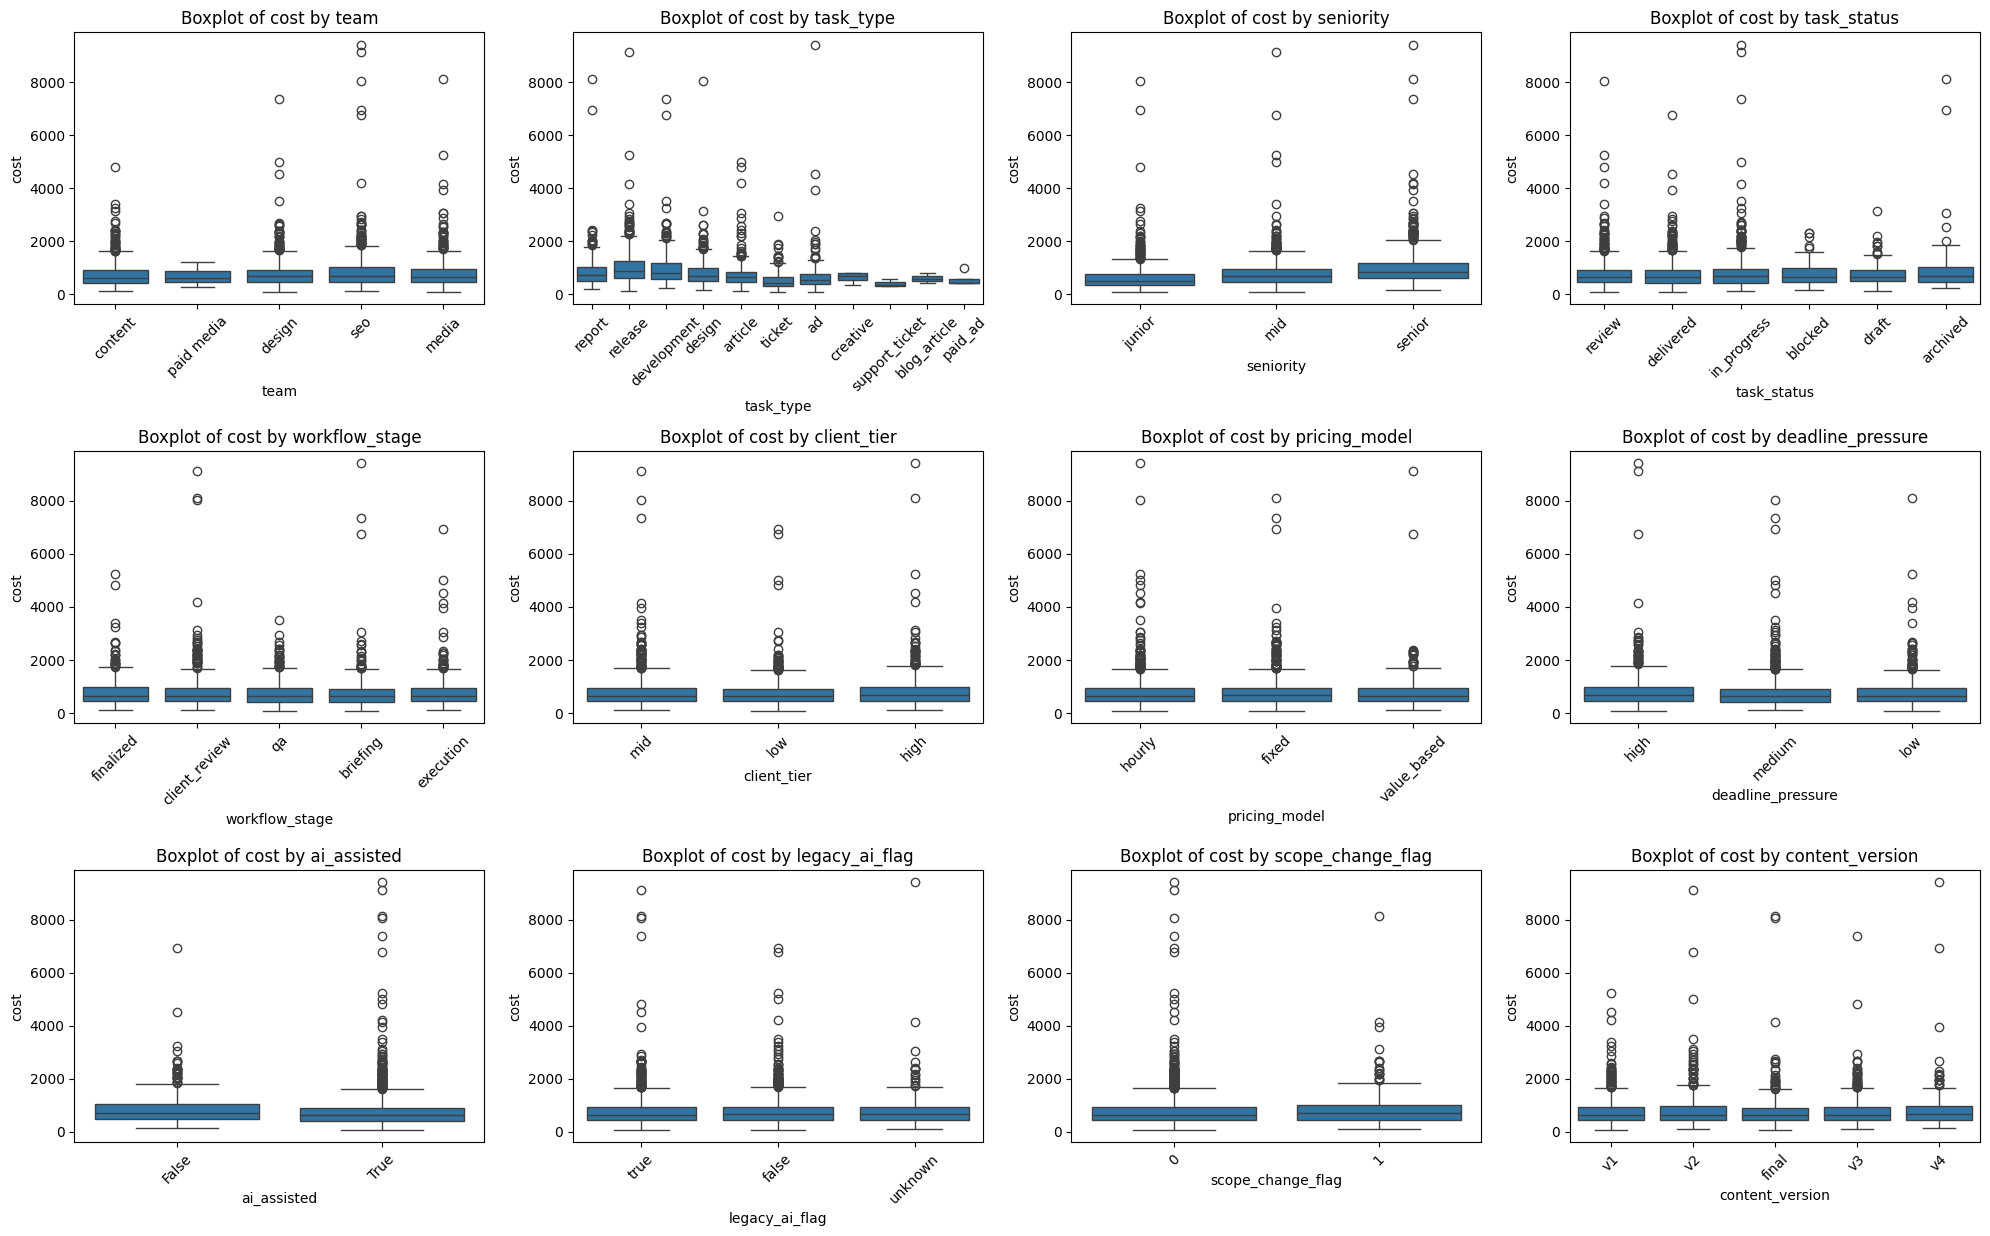

In [236]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(x=raw_df[col], y=raw_df["cost"])
    plt.title(f"Boxplot of cost by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## NEW VARIABLES: VALUE CREATION METRICS

In [242]:
raw_df["efficiency"]= raw_df["billable_hours"] / raw_df["hours_spent"]
raw_df["rework_ratio"] = raw_df["rework_hours"] / raw_df["hours_spent"]
raw_df["cost_ratio"] = raw_df["cost"] / raw_df["revenue"]

# A value near 1 means that most of the hours spent on the task were billable, while a value near 0 indicates that most of the hours were non-billable. 
# This metric can help identify tasks or projects that are more efficient in terms of billable time versus total time spent.

# how much cost is spent for each dollar of revenue (cost ratio). 

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version,efficiency,profit_per_hour
0,T00000,Client_F,P038,mid,content,report,junior,2,3.0,high,...,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1,0.673657,19.913499
1,T00001,Client_H,P028,low,paid media,release,junior,1,2.0,medium,...,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1,0.863445,52.923319
2,T00002,Client_D,P009,low,design,development,junior,3,4.0,medium,...,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2,0.727811,119.414201
3,T00003,Client_E,P023,mid,content,design,mid,3,2.0,low,...,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1,0.854321,30.489594
4,T00004,Client_C,P014,low,design,article,senior,2,5.0,low,...,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2,0.748735,63.183811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3243,T02060,Client_F,P056,mid,seo,report,mid,2,3.0,high,...,-118.60,user_101,2025-12-31,in_progress,briefing,JIRA-90491,true,v1,0.047223,-0.694012
3244,T02295,Client_K,P001,low,seo,report,mid,1,2.0,high,...,-101.08,user_096,2026-03-05,in_progress,briefing,JIRA-19154,true,v3,0.702450,-7.282421
3245,T02652,Client_C,P027,mid,content,development,junior,4,3.0,medium,...,115.35,user_080,2025-11-20,in_progress,execution,JIRA-32851,true,v4,0.775465,6.317087
3246,T01915,Client_F,P016,mid,seo,ticket,mid,3,3.0,medium,...,11.70,user_011,2026-01-08,review,client_review,NaN,false,v1,0.702186,3.196721


## NEW VARIABLES: QUALITY AND OUTPUT METRICS

In [244]:
## NEW VARIABLES: SPEED

0       0.275229
1       0.470588
2       0.320710
3       0.000000
4       0.141653
          ...   
3243    0.027796
3244    0.379683
3245    0.251369
3246    0.409836
3247    0.107793
Name: rework_ratio, Length: 3248, dtype: float64

In [ ]:
raw_df["delivery_time"]= (raw_df["delivered_at"] - raw_df["created_at"]).dt.days
(raw_df['delivered_at'] < raw_df['created_at']).sum()
col_to_see = ["task_id", "created_at", "delivered_at", "project_id", "team"]

raw_df[raw_df["delivered_at"] < raw_df["created_at"]][col_to_see]

# we need to handle these 14 negative values, probably they put the values of delivered_at and created_at in the wrong order


task_id    client project_id client_tier        team    task_type  \
0     T00000  Client_F       P038         mid     content       report   
1     T00001  Client_H       P028         low  paid media      release   
2     T00002  Client_D       P009         low      design  development   
3     T00003  Client_E       P023         mid     content       design   
4     T00004  Client_C       P014         low      design      article   
...      ...       ...        ...         ...         ...          ...   
3243  T02060  Client_F       P056         mid         seo       report   
3244  T02295  Client_K       P001         low         seo       report   
3245  T02652  Client_C       P027         mid     content  development   
3246  T01915  Client_F       P016         mid         seo       ticket   
3247  T01359  Client_A       P047        high         seo       design   

     seniority  task_complexity_score  brief_quality_score deadline_pressure  \
0       junior                      2                  3.0              high   
1       junior                      1                  2.0            medium   
2       junior                      3                  4.0            medium   
3          mid                      3                  2.0               low   
4       senior                      2                  5.0               low   
...        ...                    ...                  ...               ...   
3243       mid                      2                  3.0              high   
3244       mid                      1                  2.0              high   
3245    junior                      4                  3.0            medium   
3246       mid                      3                  3.0            medium   
3247       mid                      2                  3.0               low   

      ...  workflow_stage jira_ticket legacy_ai_flag content_version  \
0     ...       finalized  JIRA-49014           true              v1   
1     ...   client_review  JIRA-84793          false              v1   
2     ...              qa  JIRA-42485           true              v2   
3     ...        briefing  JIRA-53111          false              v1   
4     ...       execution  JIRA-86006           true              v2   
...   ...             ...         ...            ...             ...   
3243  ...        briefing  JIRA-90491           true              v1   
3244  ...        briefing  JIRA-19154           true              v3   
3245  ...       execution  JIRA-32851           true              v4   
3246  ...   client_review         NaN          false              v1   
3247  ...              qa  JIRA-39958          false              v3   

      efficiency  profit_per_hour  rework_ratio    margin  cost_ratio  \
0       0.673657        19.913499      0.275229  0.305033    0.694967   
1       0.863445        52.923319      0.470588  0.594834    0.405166   
2       0.727811       119.414201      0.320710  0.734351    0.265649   
3       0.854321        30.489594      0.000000  0.363321    0.636679   
4       0.748735        63.183811      0.141653  0.527755    0.472245   
...          ...              ...           ...       ...         ...   
3243    0.047223        -0.694012      0.027796 -0.172141    1.172141   
3244    0.702450        -7.282421      0.379683 -0.177134    1.177134   
3245    0.775465         6.317087      0.251369  0.081284    0.918716   
3246    0.702186         3.196721      0.409836  0.041012    0.958988   
3247    0.827385        31.099053      0.107793  0.356842    0.643158   

      delivery_time  
0               5.0  
1               2.0  
2               7.0  
3               3.0  
4               4.0  
...             ...  
3243            5.0  
3244            6.0  
3245            7.0  
3246            5.0  
3247            6.0  

[3248 rows x 40 columns]

In [ ]:
raw_df["ai_complexity"] = raw_df["task_complexity_score"] * raw_df["ai_usage_pct"]

# Task complexity is measured on a discrete scale from 1 to 5. This new column is a proxy to see whether the effectiveness of AI varies across different levels of complexity.



count    3210.000000
mean        4.480374
std         1.806748
min        -3.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: delivery_time, dtype: float64

In [103]:
raw_df["error_rate"] = raw_df["errors"] / raw_df["hours_spent"]

#bins su ai_usage_pct: 0-20% /20-50% / 50%+ chiamandola ai_group
raw_df["ai_group"] = pd.cut(raw_df["ai_usage_pct"], bins=[-1, 0.2, 0.5, 1], labels=["0-20%", "20-50%", "50%+"])
raw_df["ai_group"].value_counts()

raw_df

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,legacy_ai_flag,content_version,efficiency,profit_per_hour,rework_ratio,margin,cost_ratio,delivery_time,error_rate,ai_group
0,T00000,Client_F,P038,mid,content,report,junior,2,3.0,high,...,true,v1,0.673657,19.913499,0.275229,0.305033,0.694967,5.0,0.131062,50%+
1,T00001,Client_H,P028,low,paid media,release,junior,1,2.0,medium,...,false,v1,0.863445,52.923319,0.470588,0.594834,0.405166,2.0,0.105042,0-20%
2,T00002,Client_D,P009,low,design,development,junior,3,4.0,medium,...,true,v2,0.727811,119.414201,0.320710,0.734351,0.265649,7.0,0.000000,20-50%
3,T00003,Client_E,P023,mid,content,design,mid,3,2.0,low,...,false,v1,0.854321,30.489594,0.000000,0.363321,0.636679,3.0,0.035273,0-20%
4,T00004,Client_C,P014,low,design,article,senior,2,5.0,low,...,true,v2,0.748735,63.183811,0.141653,0.527755,0.472245,4.0,0.337268,0-20%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3243,T02060,Client_F,P056,mid,seo,report,mid,2,3.0,high,...,true,v1,0.047223,-0.694012,0.027796,-0.172141,1.172141,5.0,0.000000,20-50%
3244,T02295,Client_K,P001,low,seo,report,mid,1,2.0,high,...,true,v3,0.702450,-7.282421,0.379683,-0.177134,1.177134,6.0,0.000000,0-20%
3245,T02652,Client_C,P027,mid,content,development,junior,4,3.0,medium,...,true,v4,0.775465,6.317087,0.251369,0.081284,0.918716,7.0,0.054765,50%+
3246,T01915,Client_F,P016,mid,seo,ticket,mid,3,3.0,medium,...,false,v1,0.702186,3.196721,0.409836,0.041012,0.958988,5.0,0.000000,20-50%
